# Entregable 2 — Experimentación Metodológica y Análisis Principal
## Predicción de Deserción Estudiantil: Invarianza entre PreTec21 y Tec21
**Equipo 7 · Desarrollo de Aplicaciones Avanzadas de Ciencias Computacionales**

---
Este notebook implementa experimentación sistemática con tres aproximaciones metodológicas (K-Means, Regresión Logística, Random Forest), comparación de resultados, y documentación de experimentos negativos.

### Estructura
- Exploración inicial 
- Flujo de trabajo de preprocesamiento (filtrado, ingeniería de variables, split temporal)
-  K-Means Clustering
-  Regresión Logística
-  Random Forest
- Comparación sistemática
- Experimentos negativos

##  Exploración Inicial
Análisis exploratorio base que motivó las decisiones metodológicas.

Importacion de Librerias

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, time, os
from pathlib import Path
from scipy import stats

Importacion de modulos

In [6]:
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

Imporrtacion de Funciones especificas

In [7]:

from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score, precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import silhouette_score, davies_bouldin_score


Preconfigrucacioniones globales

In [8]:
warnings.filterwarnings('ignore')

Variables Globbales

In [9]:
SEED        = 42
TRAIN_GENS  = ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
TEST_GENS   = ['AD19', 'AD20']
TARGET      = 'retention'
K_CLUSTERS  = 4   # referencia de la Entrega 1
N_BOOTSTRAP = 1000

np.random.seed(SEED)
DATA_DIR = Path('../data')

print("Librerías cargadas correctamente.")
print(f"  sklearn  : {__import__('sklearn').__version__}")
print(f"  pandas   : {pd.__version__}")
print(f"  numpy    : {np.__version__}")

Librerías cargadas correctamente.
  sklearn  : 1.8.0
  pandas   : 2.2.3
  numpy    : 2.4.3


### Carga de datos 
La primera ejecución lee el `.xlsx` (~30 s) y guarda un CSV caché.
Las ejecuciones posteriores leen el CSV (~3 s).

In [10]:
CACHE_CSV = DATA_DIR / 'dataset_cache.csv'
XLSX_PATH = DATA_DIR / 'dataset.xlsx'

if CACHE_CSV.exists():
    t0 = time.time()
    df_raw = pd.read_csv(CACHE_CSV, low_memory=False)
    print(f"✓ Cache CSV cargado en {time.time()-t0:.1f}s  →  {df_raw.shape}")
else:
    print("Primera carga desde xlsx (puede tardar ~30s)...")
    t0 = time.time()
    df_raw = pd.read_excel(XLSX_PATH, engine='openpyxl')
    df_raw.to_csv(CACHE_CSV, index=False)
    print(f"✓ Xlsx leído y cache guardado en {time.time()-t0:.1f}s  →  {df_raw.shape}")

print(f"\nColumnas: {df_raw.columns.tolist()}")

✓ Cache CSV cargado en 1.3s  →  (143326, 50)

Columnas: ['student.id', 'generation', 'educational.model', 'level', 'gender', 'age', 'max.degree.parents', 'father.education.complete', 'father.education.summary', 'mother.education.complete', 'mother.education.summary', 'parents.exatec', 'father.exatec', 'mother.exatec', 'tec.no.tec', 'foreign', 'zone.type', 'first.generation', 'school', 'program', 'region', 'PNA', 'admission.test', 'online.test', 'english.evaluation', 'admission.rubric', 'general.math.eval', 'retention', 'FTE', 'scholarship.perc', 'scholarship.type', 'loan.perc', 'total.scholarship.loan', 'school.cost', 'id.school.origin', 'socioeconomic.level', 'social.lag', 'average.first.period', 'failed.subject.first.period', 'dropped.subject.first.period', 'dropout.semester', 'physical.education', 'cultural.diffusion', 'student.society', 'total.life.activities', 'athletic.sports', 'art.culture', 'student.society.leadership', 'life.work.mentoring', 'wellness.activities']


### Valores nulos por columna

In [11]:
nulls = df_raw.isnull().sum()
null_df = pd.DataFrame({
    'Nulos'      : nulls,
    '% del total': (nulls / len(df_raw) * 100).round(2)
}).query('Nulos > 0').sort_values('% del total', ascending=False)

print(f"Columnas con nulos: {len(null_df)}")
display(null_df)

Columnas con nulos: 5


,Nulos,% del total
average.first.period,99534,69.45
dropped.subject.first.period,99534,69.45
failed.subject.first.period,99534,69.45
admission.rubric,33489,23.37
admission.test,2177,1.52


### Desbalance de clases (dataset completo)

   Etiqueta      N     %
Desertó (0)  11639  8.12
 Retuvo (1) 131687 91.88


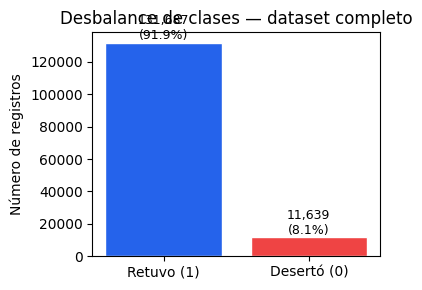

In [12]:
counts = df_raw['retention'].value_counts()
pcts   = df_raw['retention'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Etiqueta': ['Desertó (0)', 'Retuvo (1)'],
                    'N': [counts[0], counts[1]],
                    '%': [pcts[0].round(2), pcts[1].round(2)]}).to_string(index=False))

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Retuvo (1)', 'Desertó (0)'], [counts[1], counts[0]],
       color=['#2563eb', '#ef4444'], edgecolor='white')
ax.set_title('Desbalance de clases — dataset completo')
ax.set_ylabel('Número de registros')
for bar, val in zip(ax.patches, [counts[1], counts[0]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(df_raw)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

### Correlación de variables numéricas con `retention`

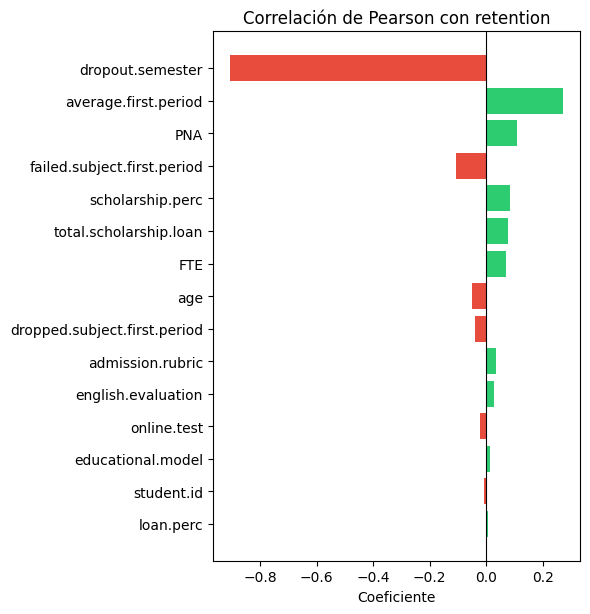

In [13]:
numeric_df = df_raw.select_dtypes(include='number')
corr = (numeric_df.corr()['retention'].drop('retention')
        .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(6, len(corr)*0.35 + 1))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Pearson con retention')
ax.set_xlabel('Coeficiente')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Flujo de trabajo de Preprocesamiento
Implementa todas las decisiones del Componente 1:

| Paso | Acción |
|------|--------|
| Filtrado | Solo universitarios (AD14–AD20) |
| Exclusión | Variables de calificaciones (grado), identificadores, fuga de datos |
| MCAR | Imputar `admission_test_norm` y `admission.rubric` con mediana |
| MAR | `total.life.activities` → bandera binaria `has_extracurriculars` |
| MNAR | `first.generation` → categoría numérica (1/0/–1) |
| Ingeniería | `apoyo_financiero`, `educ_padres_max`, encoding de categóricas |
| Split | PreTec21 (AD14–18) = entrenamiento / Tec21 (AD19–20) = prueba |

In [14]:
# ── 1.1  Filtrar: solo universitarios ──────────────────────────────────────
df = df_raw[df_raw['level'] == 'Undergraduate'].copy()
print(f"Universitarios: {len(df):,} / {len(df_raw):,} ({len(df)/len(df_raw)*100:.1f}%)")
print(f"\nDistribución por generación:")
print(df['generation'].value_counts().sort_index().to_string())
print(f"\nModel 0 (PreTec21): {(df['educational.model']==0).sum():,}")
print(f"Model 1 (Tec21)   : {(df['educational.model']==1).sum():,}")

Universitarios: 77,517 / 143,326 (54.1%)

Distribución por generación:
generation
AD14    10143
AD15    10041
AD16    10742
AD17    10788
AD18    11296
AD19    12199
AD20    12308

Model 0 (PreTec21): 53,010
Model 1 (Tec21)   : 24,507


In [15]:
# ── 1.2  Eliminar columnas con fuga o irrelevantes ─────────────────────────
DROP_COLS = [
    'student.id',
    'level',                            # constante tras filtrar
    'average.first.period',             # solo en Tec21 → fuga
    'failed.subject.first.period',      # solo en Tec21 → fuga
    'dropped.subject.first.period',     # solo en Tec21 → fuga
    'dropout.semester',                 # derivado de retention → fuga
    'program',                          # alta cardinalidad, irrelevante
    'id.school.origin',                 # identificador
    'scholarship.type',                 # redundante con scholarship.perc
    'school.cost',                      # redundante con socioeconomic.level
    'general.math.eval',               # escala inconsistente, baja cobertura
    'parents.exatec', 'father.exatec', 'mother.exatec',   # redundantes
    'father.education.complete', 'father.education.summary',
    'mother.education.complete', 'mother.education.summary',
    'scholarship.perc', 'loan.perc',    # ya están en total.scholarship.loan
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
print(f"Columnas tras exclusión: {df.shape[1]}  →  {df.columns.tolist()}")

Columnas tras exclusión: 30  →  ['generation', 'educational.model', 'gender', 'age', 'max.degree.parents', 'tec.no.tec', 'foreign', 'zone.type', 'first.generation', 'school', 'region', 'PNA', 'admission.test', 'online.test', 'english.evaluation', 'admission.rubric', 'retention', 'FTE', 'total.scholarship.loan', 'socioeconomic.level', 'social.lag', 'physical.education', 'cultural.diffusion', 'student.society', 'total.life.activities', 'athletic.sports', 'art.culture', 'student.society.leadership', 'life.work.mentoring', 'wellness.activities']


In [16]:
# ── 1.3  MCAR: normalizar admission.test (PAA 400-1600 y PAL 0-100) ────────
def norm_admission_test(val):
    """Normaliza PAA (>100) y PAL (0-100) a escala 0-1. 'Does not apply' → NaN."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s.lower().startswith('does not'):
        return np.nan
    try:
        f = float(s)
        if f > 100:                    # PAA (rango 400–1600)
            return max(0.0, (f - 400) / 1200.0)
        elif f >= 0:                   # PAL (rango 0–100)
            return f / 100.0
    except Exception:
        pass
    return np.nan

df['admission_test_norm'] = df['admission.test'].apply(norm_admission_test)
df.drop(columns=['admission.test'], inplace=True)

# Imputar MCAR con mediana
med_at = df['admission_test_norm'].median()
med_ar = df['admission.rubric'].median()
df['admission_test_norm'].fillna(med_at, inplace=True)
df['admission.rubric'].fillna(med_ar, inplace=True)

print(f"admission_test_norm  — median imputado: {med_at:.3f}  | nulos restantes: {df['admission_test_norm'].isna().sum()}")
print(f"admission.rubric     — median imputado: {med_ar:.2f} | nulos restantes: {df['admission.rubric'].isna().sum()}")

admission_test_norm  — median imputado: 0.808  | nulos restantes: 0
admission.rubric     — median imputado: 36.00 | nulos restantes: 0


In [17]:
# ── 1.4  MAR: bandera binaria has_extracurriculars ──────────────────────────
ACTIVITY_COLS = [
    'physical.education', 'cultural.diffusion', 'student.society',
    'total.life.activities', 'athletic.sports', 'art.culture',
    'student.society.leadership', 'life.work.mentoring', 'wellness.activities'
]

def parse_activity(val):
    """Devuelve 1 si el estudiante participó en alguna actividad, 0 en otro caso."""
    if pd.isna(val):
        return 0
    s = str(val).strip()
    if s in ('Does not apply', 'No information', '', '0', '0.0'):
        return 0
    try:
        return int(float(s) > 0)
    except Exception:
        return 0

df['has_extracurriculars'] = df['total.life.activities'].apply(parse_activity)
df.drop(columns=[c for c in ACTIVITY_COLS if c in df.columns], inplace=True)
print(f"has_extracurriculars  →  con actividades: {df['has_extracurriculars'].sum():,} ({df['has_extracurriculars'].mean()*100:.1f}%)")

has_extracurriculars  →  con actividades: 30,371 (39.2%)


In [18]:
# ── 1.5  MNAR: first.generation → 3 categorías numéricas ──────────────────
def encode_first_gen(val):
    """Yes=1, No=0, No information=-1 (patrón MNAR; el modelo aprende la ausencia)."""
    s = str(val).strip()
    if s == 'Yes':           return  1
    if s == 'No':            return  0
    return -1   # 'No information'

df['first_gen_enc'] = df['first.generation'].apply(encode_first_gen)
df.drop(columns=['first.generation'], inplace=True)

vals = df['first_gen_enc'].value_counts().sort_index()
print("first_gen_enc — distribución:")
print(f"  -1 (No info / MNAR): {vals.get(-1,0):>6,} ({vals.get(-1,0)/len(df)*100:.1f}%)")
print(f"   0 (No)            : {vals.get(0,0):>6,} ({vals.get(0,0)/len(df)*100:.1f}%)")
print(f"   1 (Yes)           : {vals.get(1,0):>6,} ({vals.get(1,0)/len(df)*100:.1f}%)")

first_gen_enc — distribución:
  -1 (No info / MNAR): 37,372 (48.2%)
   0 (No)            : 34,752 (44.8%)
   1 (Yes)           :  5,393 (7.0%)


In [19]:
# ── 1.6  Ingeniería: educ_padres_max ────────────────────────────────────────
EDU_ORD = {
    'No information':     0,
    'No degree':          1,
    'Undergraduate degree': 2,
    'Master degree':      3,
    'PhD':                4,
}
df['educ_padres_max'] = df['max.degree.parents'].map(EDU_ORD).fillna(0).astype(int)
df.drop(columns=['max.degree.parents'], inplace=True)

# ── 1.7  apoyo_financiero = total.scholarship.loan (ya está calculado) ─────
df.rename(columns={'total.scholarship.loan': 'apoyo_financiero'}, inplace=True)

# ── 1.8  Encoding de categóricas ────────────────────────────────────────────
# gender
df['gender_enc'] = df['gender'].map({'Male': 1, 'Female': 0}).fillna(0).astype(int)
df.drop(columns=['gender'], inplace=True)

# tec.no.tec
df['tec_enc'] = df['tec.no.tec'].map({'TEC': 1, 'NO TEC': 0}).fillna(0).astype(int)
df.drop(columns=['tec.no.tec'], inplace=True)

# foreign
df['foreign_enc'] = df['foreign'].map({'Local': 0, 'Yes: National': 1, 'Yes: Foreigner': 2}).fillna(0).astype(int)
df.drop(columns=['foreign'], inplace=True)

# zone.type
df['zone_enc'] = df['zone.type'].map({'Rural': 0, 'Semiurban': 1, 'Urban': 2, 'No information': 1}).fillna(1).astype(int)
df.drop(columns=['zone.type'], inplace=True)

# socioeconomic.level → ordinal 0-7
sec_map = {'No information': 0, 'Level 1': 1, 'Level 2': 2, 'Level 3': 3,
           'Level 4': 4, 'Level 5': 5, 'Level 6': 6, 'Level 7': 7}
df['socioec_enc'] = df['socioeconomic.level'].map(sec_map).fillna(0).astype(int)
df.drop(columns=['socioeconomic.level'], inplace=True)

# social.lag
lag_map = {'No information': 0, 'Low': 1, 'Medium': 2, 'High': 3}
df['social_lag_enc'] = df['social.lag'].map(lag_map).fillna(0).astype(int)
df.drop(columns=['social.lag'], inplace=True)

# region → label encode
le_region = LabelEncoder()
df['region_enc'] = le_region.fit_transform(df['region'].fillna('Unknown'))
df.drop(columns=['region'], inplace=True)

# school → guardar string para análisis heterogeneidad + label encode
le_school = LabelEncoder()
df['school_enc'] = le_school.fit_transform(df['school'].fillna('Unknown'))
# conservamos columna 'school' para análisis de subgrupos

print("Columnas finales:", df.columns.tolist())
print("Shape final:", df.shape)
print("\nMissing restante:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Columnas finales: ['generation', 'educational.model', 'age', 'school', 'PNA', 'online.test', 'english.evaluation', 'admission.rubric', 'retention', 'FTE', 'apoyo_financiero', 'admission_test_norm', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'gender_enc', 'tec_enc', 'foreign_enc', 'zone_enc', 'socioec_enc', 'social_lag_enc', 'region_enc', 'school_enc']
Shape final: (77517, 23)

Missing restante:
Series([], dtype: int64)


In [49]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2.1 — K-MEANS: Perfiles sobre Tec20, aplicación en Tec21
# Metodología: entrenar solo en Tec20, asignar Tec21 con predict (sin reentrenar)
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1.9 Split temporal ────────────────────────────────────────────────────────
FEATURE_COLS = [
    'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric',
    'FTE', 'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc',
    'educ_padres_max', 'age', 'gender_enc', 'tec_enc', 'foreign_enc',
    'zone_enc', 'socioec_enc', 'social_lag_enc', 'region_enc',
    'school_enc', 'online.test'
]

# Variables de perfil para clustering:
# Contexto socioeconómico, capital educativo familiar, integración institucional,
# recursos y variables previas — NO ligadas a desempeño universitario.
# Se excluye tec_enc para no contaminar el clustering con el régimen.
CLUSTER_COLS = [ 'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric', 'FTE', 'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'age', 'gender_enc', 'tec_enc', 'foreign_enc', 'zone_enc', 'socioec_enc', 'social_lag_enc', 'region_enc', 'school_enc', 'online.test' ]

# Máscaras temporales
tec20_mask = df['generation'].isin(TRAIN_GENS)   # Tec20
tec21_mask  = df['generation'].isin(TEST_GENS)    # Tec21

# Arrays para modelos supervisados (RF / RL)
X_train = df.loc[tec20_mask, FEATURE_COLS].values
y_train = df.loc[tec20_mask, TARGET].values
X_test  = df.loc[tec21_mask,  FEATURE_COLS].values
y_test  = df.loc[tec21_mask,  TARGET].values

print(f"Entrenamiento (Tec20) : {X_train.shape[0]:>6,} filas — "
      f"deserción: {(y_train==0).mean()*100:.1f}%")
print(f"Prueba       (Tec21) : {X_test.shape[0]:>6,} filas — "
      f"deserción: {(y_test==0).mean()*100:.1f}%")
print(f"\nFeatures del modelo   : {len(FEATURE_COLS)}")
print(f"Features de clustering: {len(CLUSTER_COLS)}")

# ── Imputación final de seguridad (mediana del train) ─────────────────────────
from sklearn.impute import SimpleImputer

_nan_per_col = pd.isna(X_train).sum(axis=0)
if _nan_per_col.sum() > 0:
    print("\n⚠ NaN residuales en X_train:")
    for col, n in zip(FEATURE_COLS, _nan_per_col):
        if n > 0:
            print(f"  {col}: {n}")
else:
    print("\n✓ X_train sin NaN tras preprocesamiento")

imputer_final = SimpleImputer(strategy='median')
X_train = imputer_final.fit_transform(X_train)
X_test  = imputer_final.transform(X_test)
print("✓ Imputación de seguridad aplicada — X_train y X_test libres de NaN")


Entrenamiento (Tec20) : 53,010 filas — deserción: 8.8%
Prueba       (Tec21) : 24,507 filas — deserción: 8.7%

Features del modelo   : 19
Features de clustering: 19

✓ X_train sin NaN tras preprocesamiento
✓ Imputación de seguridad aplicada — X_train y X_test libres de NaN


# NUEVO AGREGAR CLUSTERS DE VICKY

In [54]:
import pandas as pd

# =========================
# Cargar archivos originales
# =========================

df_train_clusters = pd.read_csv(DATA_DIR / "v5_dataset_pre_tec21_clusters.csv")
df_test_clusters = pd.read_csv(DATA_DIR / "v5_dataset_tec21_clusters.csv")


# ======================================================
# Verificar tamaños
# ======================================================

print("Filas X_train:", len(X_train))
print("Filas archivo train:", len(df_train_clusters))

print("Filas X_test:", len(X_test))
print("Filas archivo test:", len(df_test_clusters))


if len(X_train) != len(df_train_clusters):
    raise ValueError("X_train y train NO tienen el mismo tamaño")

if len(X_test) != len(df_test_clusters):
    raise ValueError("X_test y test NO tienen el mismo tamaño")


# ======================================================
# Convertir X_train y X_test a DataFrame
# ======================================================

cluster_train = pd.DataFrame(X_train)
cluster_test = pd.DataFrame(X_test)


# ======================================================
# Agregar columna cluster
# ======================================================

cluster_train["cluster"] = df_train_clusters["cluster_id"].values
cluster_test["cluster"] = df_test_clusters["cluster_id"].values

cluster_train["retention"] = y_train
cluster_test["retention"] = y_test

# ======================================================
# Verificación final
# ======================================================

print(cluster_train.head())
print(cluster_test.head())

Filas X_train: 53010
Filas archivo train: 53010
Filas X_test: 24507
Filas archivo test: 24507
       0         1    2     3     4         5    6    7    8     9  ...   11  \
0  87.00  0.808333  6.0  36.0  1.08  0.000000  0.0 -1.0  0.0  19.0  ...  1.0   
1  83.76  0.808333  6.0  36.0  1.08  0.599998  1.0  0.0  2.0  23.0  ...  1.0   
2  71.00  0.683333  6.0  24.0  1.08  0.000000  0.0 -1.0  0.0  19.0  ...  0.0   
3  96.86  0.940833  6.0  36.0  1.08  0.900003  0.0 -1.0  0.0  17.0  ...  1.0   
4  95.19  0.931667  6.0  36.0  1.08  0.400028  0.0 -1.0  0.0  17.0  ...  1.0   

    12   13   14   15   16   17   18  cluster  retention  
0  1.0  1.0  0.0  0.0  4.0  5.0  0.0        3          1  
1  1.0  1.0  0.0  0.0  3.0  3.0  0.0        1          0  
2  2.0  1.0  0.0  0.0  4.0  5.0  0.0        4          1  
3  1.0  1.0  0.0  0.0  3.0  3.0  0.0        1          1  
4  0.0  1.0  0.0  0.0  0.0  5.0  0.0        1          1  

[5 rows x 21 columns]
       0         1    2     3    4    5    6    

## K-Means Clustering IGNORAR
**Objetivo:** identificar perfiles latentes de riesgo sin etiquetas supervisadas y evaluar si esos perfiles persisten entre PreTec21 y Tec21 (invarianza).

**Protocolo:**
1. Estandarizar las variables del clustering con el escalador ajustado en PreTec21.
2. Determinar k óptimo con el método del codo + Silhouette.
3. Ajustar K-Means independientemente en PreTec21 y en Tec21.
4. Alinear clusters por similitud de perfiles z-score (coseno).
5. Reportar invarianza: variación < 15% en z-score por variable clave.


Train clustering shape: (53010, 19)
Test  clustering shape: (24507, 19)


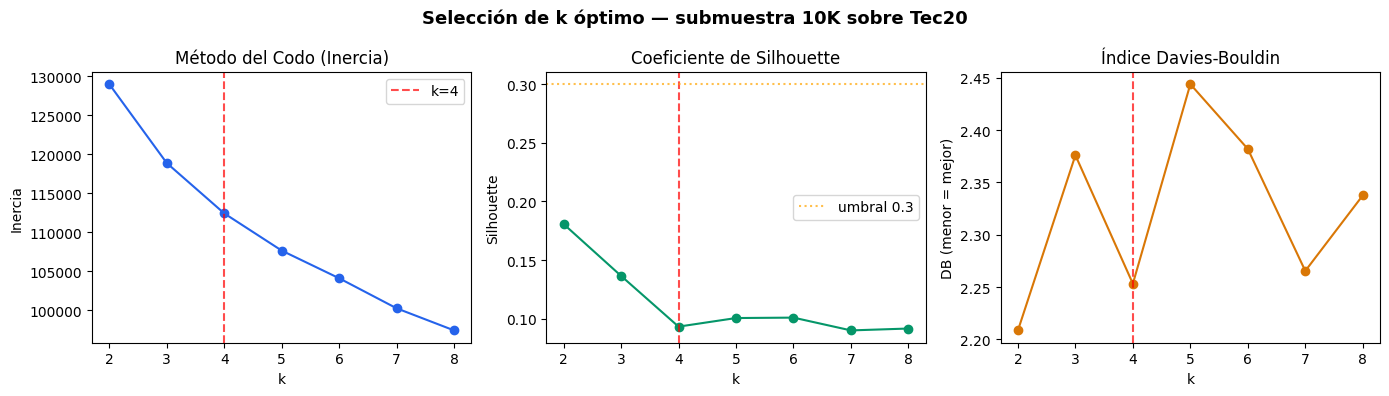


k=4 — Silhouette: 0.093 | Davies-Bouldin: 2.253

═══ Perfiles Tec20 ═══
             n  dropout_rate  pct_total
cluster                                
0        10842         0.143       20.5
2        15609         0.084       29.4
3        15077         0.082       28.4
1        11482         0.051       21.7


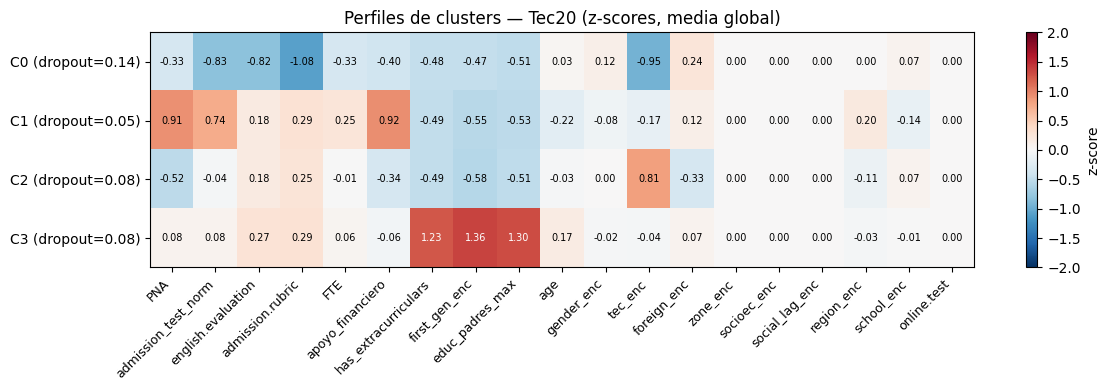


═══ Perfiles Tec21 (con centroides de Tec20) ═══
             n  dropout_rate  pct_total
cluster                                
0          836         0.190        3.4
2          328         0.146        1.3
3        23103         0.082       94.3
1          240         0.071        1.0

═══ Distribución comparativa Tec20 vs Tec21 ═══
         Tec20_%  Tec21_%  Tec20_dropout  Tec21_dropout  Δ_pct  Δ_dropout
cluster                                                                  
0           20.5      3.4          0.143          0.190  -17.1      0.047
2           29.4      1.3          0.084          0.146  -28.1      0.062
3           28.4     94.3          0.082          0.082   65.9      0.000
1           21.7      1.0          0.051          0.071  -20.7      0.020


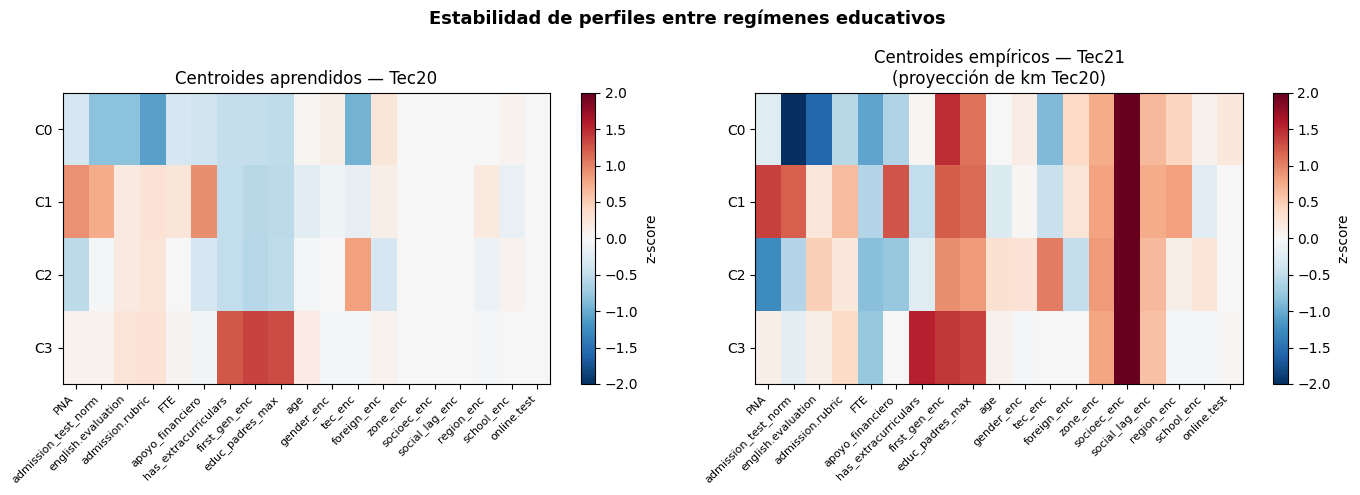


Diferencia absoluta de z-score (centroide Tec20 vs empírico Tec21):
      PNA  admission_test_norm  english.evaluation  admission.rubric    FTE  apoyo_financiero  has_extracurriculars  first_gen_enc  educ_padres_max    age  gender_enc  tec_enc  foreign_enc  zone_enc  socioec_enc  social_lag_enc  region_enc  school_enc  online.test
C0  0.088                1.435               0.749             0.533  0.725             0.201                 0.522          1.946            1.602  0.037       0.037    0.067        0.152     0.748        3.086           0.653       0.432       0.007        0.212
C1  0.454                0.455               0.038             0.335  0.833             0.333                 0.005          1.754            1.665  0.055       0.098    0.278        0.139     0.804        3.462           0.738       0.627       0.063        0.008
C2  0.744                0.547               0.300             0.039  0.829             0.409                 0.257          1.508      

In [ ]:
#METODO 1 APLICAR CLUSTERS DE TEC 20 A TEC 21
# ── 2.1a.1 Preparar datos de clustering ──────────────────────────────────────
X_clust_train_df = df.loc[tec20_mask, CLUSTER_COLS].copy()
X_clust_test_df  = df.loc[tec21_mask,  CLUSTER_COLS].copy()

# Imputar con mediana del train (nunca del test)
clust_medians = X_clust_train_df.median()
X_clust_train_df.fillna(clust_medians, inplace=True)
X_clust_test_df.fillna(clust_medians, inplace=True)

# Escalar con estadísticos del train
scaler_clust   = StandardScaler()
X_clust_train  = scaler_clust.fit_transform(X_clust_train_df)
X_clust_test   = scaler_clust.transform(X_clust_test_df)

print(f"\nTrain clustering shape: {X_clust_train.shape}")
print(f"Test  clustering shape: {X_clust_test.shape}")


# ── 2.1a.2 Selección de k óptimo (solo sobre Tec20) ──────────────────────────
inertias, silhouettes, db_scores = [], [], []
K_RANGE = range(2, 9)

rng     = np.random.default_rng(SEED)
idx_sub = rng.choice(len(X_clust_train),
                     size=min(10_000, len(X_clust_train)), replace=False)
X_sub   = X_clust_train[idx_sub]

for k in K_RANGE:
    km    = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lbls  = km.fit_predict(X_sub)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sub, lbls,
                                        sample_size=3_000, random_state=SEED))
    db_scores.append(davies_bouldin_score(X_sub, lbls))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(list(K_RANGE), inertias,    'o-', color='#2563eb')
axes[0].set_title('Método del Codo (Inercia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[0].axvline(K_CLUSTERS, color='red', linestyle='--', alpha=0.7,
                label=f'k={K_CLUSTERS}'); axes[0].legend()

axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='#059669')
axes[1].set_title('Coeficiente de Silhouette')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].axvline(K_CLUSTERS, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(0.3, color='orange', linestyle=':', alpha=0.7, label='umbral 0.3')
axes[1].legend()

axes[2].plot(list(K_RANGE), db_scores,   'o-', color='#d97706')
axes[2].set_title('Índice Davies-Bouldin')
axes[2].set_xlabel('k'); axes[2].set_ylabel('DB (menor = mejor)')
axes[2].axvline(K_CLUSTERS, color='red', linestyle='--', alpha=0.7)

plt.suptitle('Selección de k óptimo — submuestra 10K sobre Tec20',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nk={K_CLUSTERS} — "
      f"Silhouette: {silhouettes[K_CLUSTERS-2]:.3f} | "
      f"Davies-Bouldin: {db_scores[K_CLUSTERS-2]:.3f}")


# ── 2.1a.3 Entrenar K-Means en Tec20 ─────────────────────────────────────────
km_final = KMeans(n_clusters=K_CLUSTERS, n_init=20, random_state=SEED)
km_final.fit(X_clust_train)          # entrena SOLO en Tec20

labels_train = km_final.labels_      # asignación Tec20

# DataFrames enriquecidos con columna cluster
df_train_profiles = df.loc[tec20_mask].copy()
df_train_profiles['cluster'] = labels_train

cluster_stats_train = (
    df_train_profiles
    .groupby('cluster')
    .agg(n=('retention', 'count'),
         dropout_rate=('retention', lambda x: (x == 0).mean()))
    .round(3)
)
cluster_stats_train['pct_total'] = (
    cluster_stats_train['n'] / len(df_train_profiles) * 100
).round(1)
cluster_stats_train = cluster_stats_train.sort_values('dropout_rate', ascending=False)

print("\n═══ Perfiles Tec20 ═══")
print(cluster_stats_train.to_string())

# Heatmap de centroides (z-scores respecto a media global del train)
centers_df = pd.DataFrame(km_final.cluster_centers_, columns=CLUSTER_COLS)
centers_df.index = [f'C{i}' for i in range(K_CLUSTERS)]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(centers_df.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(CLUSTER_COLS)))
ax.set_xticklabels(CLUSTER_COLS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(K_CLUSTERS))
ax.set_yticklabels(
    [f'C{i} (dropout={cluster_stats_train.loc[i, "dropout_rate"]:.2f})'
     for i in range(K_CLUSTERS)]
)
plt.colorbar(im, ax=ax, label='z-score')
ax.set_title('Perfiles de clusters — Tec20 (z-scores, media global)',
             fontsize=12)
for i in range(K_CLUSTERS):
    for j in range(len(CLUSTER_COLS)):
        v = centers_df.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(v) > 1.2 else 'black')
plt.tight_layout(); plt.show()


# ── 2.1a.4 Aplicar centroides Tec20 → Tec21 con predict ──────────────────────
# CLAVE: no se reentrena, se usa km_final.predict para proyectar Tec21
# sobre los perfiles aprendidos en Tec20.
labels_test = km_final.predict(X_clust_test)

df_test_profiles = df.loc[tec21_mask].copy()
df_test_profiles['cluster'] = labels_test

cluster_stats_test = (
    df_test_profiles
    .groupby('cluster')
    .agg(n=('retention', 'count'),
         dropout_rate=('retention', lambda x: (x == 0).mean()))
    .round(3)
)
cluster_stats_test['pct_total'] = (
    cluster_stats_test['n'] / len(df_test_profiles) * 100
).round(1)
cluster_stats_test = cluster_stats_test.sort_values('dropout_rate', ascending=False)

print("\n═══ Perfiles Tec21 (con centroides de Tec20) ═══")
print(cluster_stats_test.to_string())


# ── 2.1a.5 Comparación de distribución de clusters entre regímenes ────────────
print("\n═══ Distribución comparativa Tec20 vs Tec21 ═══")
comp = pd.DataFrame({
    'Tec20_%': cluster_stats_train['pct_total'],
    'Tec21_%': cluster_stats_test['pct_total'],
    'Tec20_dropout': cluster_stats_train['dropout_rate'],
    'Tec21_dropout': cluster_stats_test['dropout_rate'],
}).round(3)
comp['Δ_pct']     = (comp['Tec21_%']     - comp['Tec20_%']).round(1)
comp['Δ_dropout'] = (comp['Tec21_dropout'] - comp['Tec20_dropout']).round(3)
print(comp.to_string())

# Heatmap comparativo (mismos centroides, misma escala)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
centers = km_final.cluster_centers_   # centroides únicos (Tec20)

# Para Tec21 calculamos el centroide empírico de cada cluster en el espacio escalado
centers_test_empirical = np.array([
    X_clust_test[labels_test == k].mean(axis=0)
    for k in range(K_CLUSTERS)
])

for ax, data, title in [
    (axes[0], centers,                 'Centroides aprendidos — Tec20'),
    (axes[1], centers_test_empirical,  'Centroides empíricos — Tec21\n(proyección de km Tec20)')
]:
    im = ax.imshow(data, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    ax.set_xticks(range(len(CLUSTER_COLS)))
    ax.set_xticklabels(CLUSTER_COLS, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(K_CLUSTERS))
    ax.set_yticklabels([f'C{i}' for i in range(K_CLUSTERS)])
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='z-score')

plt.suptitle('Estabilidad de perfiles entre regímenes educativos',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Diferencia absoluta entre centroide aprendido y empírico de Tec21
diff = np.abs(centers - centers_test_empirical)
diff_df = pd.DataFrame(diff, columns=CLUSTER_COLS,
                        index=[f'C{i}' for i in range(K_CLUSTERS)])
print("\nDiferencia absoluta de z-score (centroide Tec20 vs empírico Tec21):")
print(diff_df.round(3).to_string())
max_diff = diff_df.max(axis=0)
print(f"\nVariables con drift > 0.15:")
print(max_diff[max_diff > 0.15].sort_values(ascending=False).to_string())
invariant = (max_diff < 0.15).sum()
print(f"\n✓ Variables estables (Δz < 0.15): {invariant}/{len(CLUSTER_COLS)}")
print(f"✗ Variables con drift (Δz ≥ 0.15): {len(CLUSTER_COLS)-invariant}/{len(CLUSTER_COLS)}")


# ── 2.1a.6 Preparar datos para RF y Regresión Logística ──────────────────────
# Los clusters son la variable objetivo (y) para los modelos supervisados.
# X son las mismas FEATURE_COLS (sin tec_enc si se quiere evitar fuga de régimen).
# IMPORTANTE: los modelos supervisados se usan para EXPLICAR los perfiles,
# no para descubrirlos — la pregunta es "¿qué variables definen cada cluster?"

# Opcionalmente excluir tec_enc de FEATURE_COLS para evitar que el modelo
# aprenda régimen en vez de perfil:
FEATURE_COLS_RF = [c for c in FEATURE_COLS if c != 'tec_enc']

X_rf_lr_train = df_train_profiles[FEATURE_COLS_RF].values
y_rf_lr_train = df_train_profiles['cluster'].values   # etiqueta de perfil

X_rf_lr_test  = df_test_profiles[FEATURE_COLS_RF].values
y_rf_lr_test  = df_test_profiles['cluster'].values

# Imputar con el mismo imputer_final (ya ajustado en X_train sin tec_enc se recalcula)
imputer_rf = SimpleImputer(strategy='median')
X_rf_lr_train = imputer_rf.fit_transform(X_rf_lr_train)
X_rf_lr_test  = imputer_rf.transform(X_rf_lr_test)

print("\n═══ Datos listos para RF y Regresión Logística ═══")
print(f"X_rf_lr_train : {X_rf_lr_train.shape}  — features: {len(FEATURE_COLS_RF)}")
print(f"y_rf_lr_train : {y_rf_lr_train.shape}  — clusters: {np.unique(y_rf_lr_train)}")
print(f"X_rf_lr_test  : {X_rf_lr_test.shape}   — (Tec21 con etiquetas por proyección)")
print(f"y_rf_lr_test  : {y_rf_lr_test.shape}")
print(f"\nDistribución de clusters en train:")
for c, n in sorted(zip(*np.unique(y_rf_lr_train, return_counts=True))):
    print(f"  Cluster {c}: {n:>5,}  ({n/len(y_rf_lr_train)*100:.1f}%)")
print(f"\nDistribución de clusters en test (Tec21):")
for c, n in sorted(zip(*np.unique(y_rf_lr_test, return_counts=True))):
    print(f"  Cluster {c}: {n:>5,}  ({n/len(y_rf_lr_test)*100:.1f}%)")

# Checkpoints finales
print("\n─── Objetos disponibles para etapas siguientes ───")
print("  km_final          : KMeans entrenado en Tec20")
print("  scaler_clust      : StandardScaler del clustering")
print("  df_train_profiles : Tec20 + columna 'cluster'")
print("  df_test_profiles  : Tec21 + columna 'cluster' (proyectada)")
print("  X_rf_lr_train / y_rf_lr_train : Tec20 para RF/RL")
print("  X_rf_lr_test  / y_rf_lr_test  : Tec21 para RF/RL")
print("  FEATURE_COLS_RF   : features sin tec_enc")


## Regresión Logística IGNORAR
**Rol:** línea base interpretable y herramienta de comparación teórica.
Los coeficientes con IC permiten cuantificar cuánto cambia el efecto de cada predictor entre PreTec21 y Tec21.

In [ ]:
# ── 2.1b.1  Estandarizar features del modelo ────────────────────────────────
scaler_model = StandardScaler()
X_train_sc = scaler_model.fit_transform(X_train)
X_test_sc   = scaler_model.transform(X_test)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"K-Fold estratificado: k=5, seed={SEED}")
print(f"Desertores en train: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")

K-Fold estratificado: k=5, seed=42
Desertores en train: 4,685 (8.8%)


In [ ]:
# ── 2.1b.2  K-Fold CV sobre PreTec21 ────────────────────────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED, solver='lbfgs')

cv_lr = cross_validate(
    lr, X_train_sc, y_train,
    cv=skf,
    scoring=['roc_auc', 'recall', 'f1', 'precision'],
    return_train_score=True,
    n_jobs=-1
)

print("Regresión Logística — K-Fold CV (PreTec21):")
print(f"  AUC-ROC  : {cv_lr['test_roc_auc'].mean():.3f} ± {cv_lr['test_roc_auc'].std():.3f}")
print(f"  Recall   : {cv_lr['test_recall'].mean():.3f} ± {cv_lr['test_recall'].std():.3f}")
print(f"  F1-Score : {cv_lr['test_f1'].mean():.3f} ± {cv_lr['test_f1'].std():.3f}")
print(f"  Precision: {cv_lr['test_precision'].mean():.3f} ± {cv_lr['test_precision'].std():.3f}")

Regresión Logística — K-Fold CV (PreTec21):
  AUC-ROC  : 0.674 ± 0.009
  Recall   : 0.664 ± 0.005
  F1-Score : 0.780 ± 0.003
  Precision: 0.943 ± 0.002


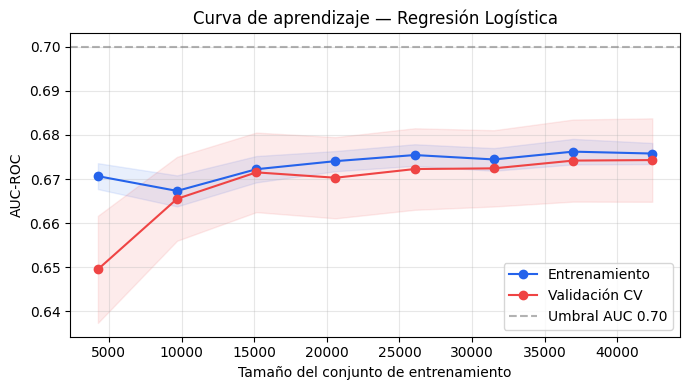

In [ ]:
# ── 2.1b.3  Curva de aprendizaje ─────────────────────────────────────────────
train_sizes, tr_scores, val_scores = learning_curve(
    lr, X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=skf, scoring='roc_auc', n_jobs=-1
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, tr_scores.mean(1),  'o-', color='#2563eb', label='Entrenamiento')
ax.plot(train_sizes, val_scores.mean(1), 'o-', color='#ef4444',  label='Validación CV')
ax.fill_between(train_sizes, tr_scores.mean(1)-tr_scores.std(1), tr_scores.mean(1)+tr_scores.std(1), alpha=0.1, color='#2563eb')
ax.fill_between(train_sizes, val_scores.mean(1)-val_scores.std(1), val_scores.mean(1)+val_scores.std(1), alpha=0.1, color='#ef4444')
ax.axhline(0.7, color='gray', linestyle='--', alpha=0.6, label='Umbral AUC 0.70')
ax.set_xlabel('Tamaño del conjunto de entrenamiento'); ax.set_ylabel('AUC-ROC')
ax.set_title('Curva de aprendizaje — Regresión Logística')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# ── 2.1b.4  Selección de umbral (OOF) + modelo final ────────────────────────
oof_proba_lr = np.zeros(len(X_train_sc))
for tr_idx, val_idx in skf.split(X_train_sc, y_train):
    lr.fit(X_train_sc[tr_idx], y_train[tr_idx])
    oof_proba_lr[val_idx] = lr.predict_proba(X_train_sc[val_idx])[:, 1]

prec_oof, rec_oof, thr_oof = precision_recall_curve(y_train, oof_proba_lr)
f1_oof = 2 * prec_oof * rec_oof / (prec_oof + rec_oof + 1e-8)
best_thr_lr = thr_oof[np.argmax(f1_oof[:-1])]
print(f"Umbral óptimo (OOF, max-F1): {best_thr_lr:.3f}")

# Modelo final entrenado en todo PreTec21
lr_final = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED, solver='lbfgs')
lr_final.fit(X_train_sc, y_train)
y_proba_lr = lr_final.predict_proba(X_test_sc)[:, 1]
y_pred_lr  = (y_proba_lr >= best_thr_lr).astype(int)

# ── Bootstrap IC 95% ────────────────────────────────────────────────────────
rng_bs = np.random.default_rng(SEED)
boot_aucs_lr, boot_rec_lr, boot_f1_lr = [], [], []
n_test = len(y_test)
for _ in range(N_BOOTSTRAP):
    idx = rng_bs.integers(0, n_test, n_test)
    if len(np.unique(y_test[idx])) < 2: continue
    boot_aucs_lr.append(roc_auc_score(y_test[idx], y_proba_lr[idx]))
    y_b = (y_proba_lr[idx] >= best_thr_lr).astype(int)
    boot_rec_lr.append(recall_score(y_test[idx], y_b, zero_division=0))
    boot_f1_lr.append(f1_score(y_test[idx], y_b, zero_division=0))

def ci(arr): return np.percentile(arr, [2.5, 97.5])
auc_lr   = roc_auc_score(y_test, y_proba_lr)
rec_lr   = recall_score(y_test, y_pred_lr)
f1_lr    = f1_score(y_test, y_pred_lr)
prec_lr  = precision_score(y_test, y_pred_lr)

print(f"\n─── Resultados en Tec21 (umbral={best_thr_lr:.2f}) ───")
print(f"  AUC-ROC  : {auc_lr:.3f}  IC95% [{ci(boot_aucs_lr)[0]:.3f}–{ci(boot_aucs_lr)[1]:.3f}]")
print(f"  Recall   : {rec_lr:.3f}  IC95% [{ci(boot_rec_lr)[0]:.3f}–{ci(boot_rec_lr)[1]:.3f}]")
print(f"  F1-Score : {f1_lr:.3f}  IC95% [{ci(boot_f1_lr)[0]:.3f}–{ci(boot_f1_lr)[1]:.3f}]")
print(f"  Precision: {prec_lr:.3f}")

Umbral óptimo (OOF, max-F1): 0.076

─── Resultados en Tec21 (umbral=0.08) ───
  AUC-ROC  : 0.655  IC95% [0.644–0.668]
  Recall   : 0.999  IC95% [0.999–1.000]
  F1-Score : 0.955  IC95% [0.953–0.956]
  Precision: 0.914


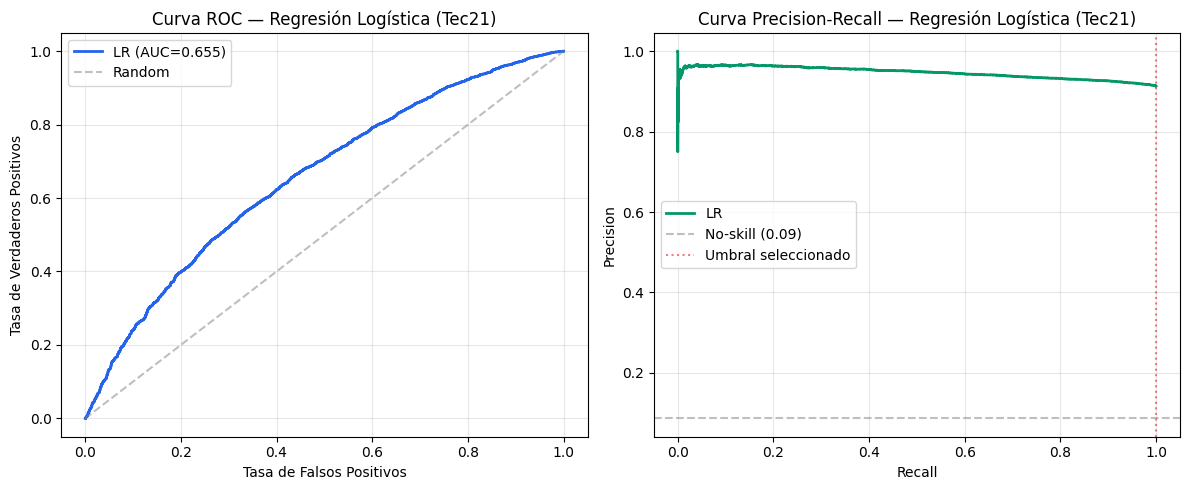

In [ ]:
# ── 2.1b.5  Curvas ROC y Precision-Recall ───────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
prec_lr_c, rec_lr_c, _ = precision_recall_curve(y_test, y_proba_lr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr_lr, tpr_lr, lw=2, color='#2563eb', label=f'LR (AUC={auc_lr:.3f})')
axes[0].plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random')
axes[0].set_xlabel('Tasa de Falsos Positivos'); axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC — Regresión Logística (Tec21)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Precision-Recall
no_skill = (y_test == 0).mean()
axes[1].plot(rec_lr_c, prec_lr_c, lw=2, color='#059669', label='LR')
axes[1].axhline(no_skill, linestyle='--', color='gray', alpha=0.5, label=f'No-skill ({no_skill:.2f})')
axes[1].axvline(rec_lr, linestyle=':', color='#ef4444', alpha=0.7, label=f'Umbral seleccionado')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Regresión Logística (Tec21)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

Perfil promedio por tipo de error:
               PNA  apoyo_financiero  has_extracurriculars  first_gen_enc
error_type                                                               
FN          72.641             0.146                 0.571          0.643
FP          86.174             0.149                 0.696          0.187
OK          88.304             0.243                 0.804          0.119


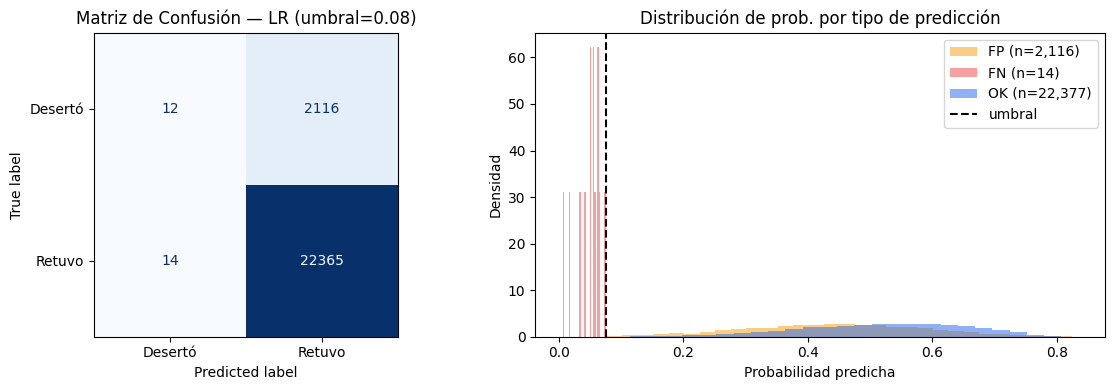

In [ ]:
# ── 2.1b.6  Matriz de confusión + análisis de errores ───────────────────────
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

disp = ConfusionMatrixDisplay(cm_lr, display_labels=['Desertó', 'Retuvo'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión — LR (umbral={best_thr_lr:.2f})')

# Error analysis: ¿qué tienen en común FP y FN?
test_df_copy = df.loc[tec21_mask].copy()
test_df_copy['y_true']  = y_test
test_df_copy['y_pred']  = y_pred_lr
test_df_copy['y_proba'] = y_proba_lr
test_df_copy['error_type'] = 'OK'
test_df_copy.loc[(test_df_copy['y_true']==1)&(test_df_copy['y_pred']==0), 'error_type'] = 'FN'
test_df_copy.loc[(test_df_copy['y_true']==0)&(test_df_copy['y_pred']==1), 'error_type'] = 'FP'

err_summary = test_df_copy.groupby('error_type')[['PNA','apoyo_financiero','has_extracurriculars','first_gen_enc']].mean()
print("Perfil promedio por tipo de error:")
print(err_summary.round(3).to_string())

# Distribución de probabilidades por tipo de error
for etype, color in [('FP','#f59e0b'), ('FN','#ef4444'), ('OK','#2563eb')]:
    sub = test_df_copy[test_df_copy['error_type']==etype]['y_proba']
    if len(sub): axes[1].hist(sub, bins=30, alpha=0.5, label=f'{etype} (n={len(sub):,})', color=color, density=True)
axes[1].axvline(best_thr_lr, color='black', linestyle='--', label='umbral')
axes[1].set_xlabel('Probabilidad predicha'); axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de prob. por tipo de predicción')
axes[1].legend()

plt.tight_layout(); plt.show()

Top 10 variables por magnitud de coeficiente:
            Variable  Coeficiente  Odds Ratio
                 FTE     0.251155    1.285510
                 PNA     0.237338    1.267870
has_extracurriculars     0.189571    1.208730
  english.evaluation     0.177564    1.194305
                 age    -0.162727    0.849823
    apoyo_financiero     0.131054    1.140030
             tec_enc     0.107410    1.113391
         foreign_enc    -0.095155    0.909232
       first_gen_enc    -0.094655    0.909687
 admission_test_norm     0.093062    1.097530


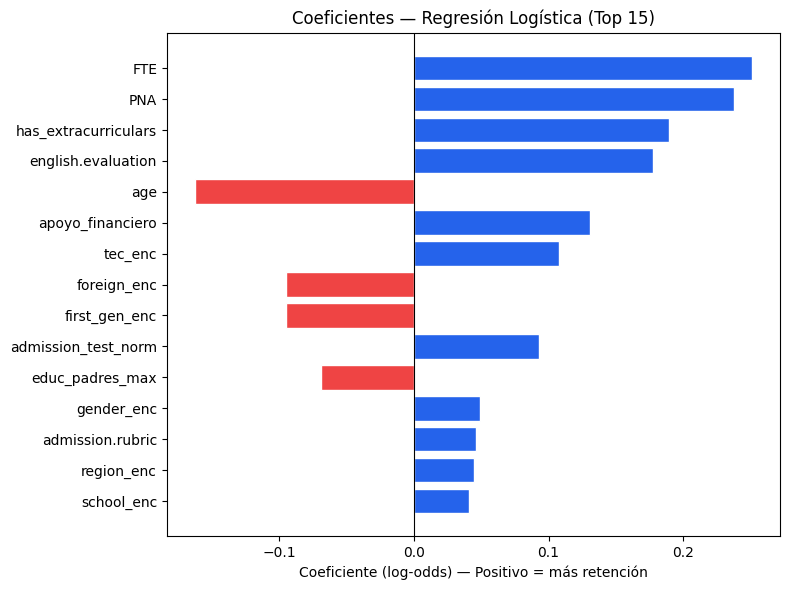

In [ ]:
# ── 2.1b.7  Coeficientes (odds ratios) ──────────────────────────────────────
coefs = lr_final.coef_[0]
odds  = np.exp(coefs)
ci_coef = 1.96 * np.std(X_train_sc, axis=0) * coefs   # aproximación Wald

coef_df = pd.DataFrame({
    'Variable'  : FEATURE_COLS,
    'Coeficiente': coefs,
    'Odds Ratio' : odds,
    'OR Lower'   : np.exp(coefs - 1.96 / np.sqrt(len(y_train))),
    'OR Upper'   : np.exp(coefs + 1.96 / np.sqrt(len(y_train))),
}).sort_values('Coeficiente', key=abs, ascending=False)

print("Top 10 variables por magnitud de coeficiente:")
print(coef_df.head(10)[['Variable','Coeficiente','Odds Ratio']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
top_coef = coef_df.head(15)
colors = ['#2563eb' if c > 0 else '#ef4444' for c in top_coef['Coeficiente']]
ax.barh(top_coef['Variable'], top_coef['Coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes — Regresión Logística (Top 15)')
ax.set_xlabel('Coeficiente (log-odds) — Positivo = más retención')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## Random Forest IGNORAR 
**Rol:** capturar interacciones no lineales entre predictores (ej. NSE × primera generación) que la regresión logística no modela sin términos de interacción explícitos.
La importancia de variables valida si las mismas features que el clustering identifica como definitorias de riesgo también emergen como las más importantes en el RF.

In [ ]:
# ── 2.1c.1  Búsqueda de hiperparámetros (RandomizedSearchCV) ─────────────────
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators'    : randint(100, 400),
    'max_depth'       : [5, 8, 12, 15, None],
    'min_samples_leaf': randint(5, 40),
    'max_features'    : ['sqrt', 'log2', 0.4],
    'class_weight'    : ['balanced', 'balanced_subsample'],
}

rf_base = RandomForestClassifier(random_state=SEED, n_jobs=1)  # n_jobs=1 evita paralelismo anidado
rscv = RandomizedSearchCV(
    rf_base, param_dist,
    n_iter=25, cv=skf,
    scoring='roc_auc',
    random_state=SEED, n_jobs=-1,   # paralelismo externo: distribuye los 25x5 fits
    verbose=1
)
print("Iniciando RandomizedSearchCV (n_iter=25, cv=5)...")
t0 = time.time()
rscv.fit(X_train_sc, y_train)
print(f"Completado en {(time.time()-t0)/60:.1f} min")
print(f"\nMejores hiperparámetros:")
for k, v in rscv.best_params_.items(): print(f"  {k}: {v}")
print(f"\nMejor AUC-ROC en CV: {rscv.best_score_:.4f}")

Iniciando RandomizedSearchCV (n_iter=25, cv=5)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Completado en 2.0 min

Mejores hiperparámetros:
  class_weight: balanced
  max_depth: 15
  max_features: sqrt
  min_samples_leaf: 31
  n_estimators: 158

Mejor AUC-ROC en CV: 0.6874


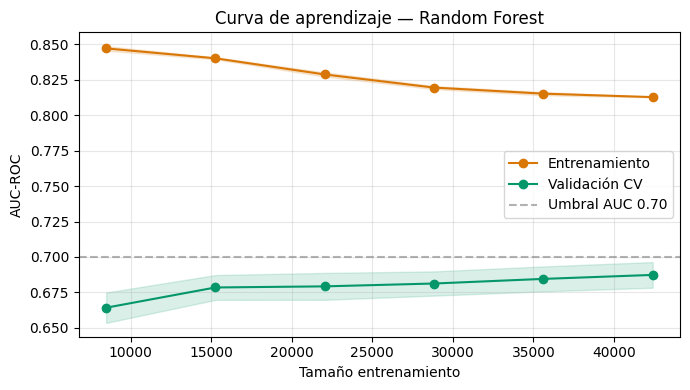

In [ ]:
# ── 2.1c.2  Curva de aprendizaje del RF final ────────────────────────────────
rf_best = rscv.best_estimator_
tr_sizes_rf, tr_sc_rf, val_sc_rf = learning_curve(
    rf_best, X_train_sc, y_train,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=skf, scoring='roc_auc', n_jobs=-1
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tr_sizes_rf, tr_sc_rf.mean(1),  'o-', color='#d97706', label='Entrenamiento')
ax.plot(tr_sizes_rf, val_sc_rf.mean(1), 'o-', color='#059669', label='Validación CV')
ax.fill_between(tr_sizes_rf, tr_sc_rf.mean(1)-tr_sc_rf.std(1), tr_sc_rf.mean(1)+tr_sc_rf.std(1), alpha=0.15, color='#d97706')
ax.fill_between(tr_sizes_rf, val_sc_rf.mean(1)-val_sc_rf.std(1), val_sc_rf.mean(1)+val_sc_rf.std(1), alpha=0.15, color='#059669')
ax.axhline(0.7, color='gray', linestyle='--', alpha=0.6, label='Umbral AUC 0.70')
ax.set_xlabel('Tamaño entrenamiento'); ax.set_ylabel('AUC-ROC')
ax.set_title('Curva de aprendizaje — Random Forest'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# ── 2.1c.3  Umbral óptimo (OOF) + métricas finales en Tec21 ─────────────────
oof_proba_rf = np.zeros(len(X_train_sc))
rf_fit = rscv.best_estimator_.__class__(**rscv.best_params_, random_state=SEED, n_jobs=1)
for tr_idx, val_idx in skf.split(X_train_sc, y_train):
    rf_fit.fit(X_train_sc[tr_idx], y_train[tr_idx])
    oof_proba_rf[val_idx] = rf_fit.predict_proba(X_train_sc[val_idx])[:, 1]

prec_oof_rf, rec_oof_rf, thr_oof_rf = precision_recall_curve(y_train, oof_proba_rf)
f1_oof_rf  = 2 * prec_oof_rf * rec_oof_rf / (prec_oof_rf + rec_oof_rf + 1e-8)
best_thr_rf = thr_oof_rf[np.argmax(f1_oof_rf[:-1])]
print(f"Umbral óptimo RF (OOF): {best_thr_rf:.3f}")

# Modelo final
rf_final = rscv.best_estimator_
rf_final.fit(X_train_sc, y_train)
y_proba_rf = rf_final.predict_proba(X_test_sc)[:, 1]
y_pred_rf  = (y_proba_rf >= best_thr_rf).astype(int)

# Bootstrap IC 95%
boot_aucs_rf, boot_rec_rf, boot_f1_rf = [], [], []
for _ in range(N_BOOTSTRAP):
    idx = rng_bs.integers(0, n_test, n_test)
    if len(np.unique(y_test[idx])) < 2: continue
    boot_aucs_rf.append(roc_auc_score(y_test[idx], y_proba_rf[idx]))
    y_b = (y_proba_rf[idx] >= best_thr_rf).astype(int)
    boot_rec_rf.append(recall_score(y_test[idx], y_b, zero_division=0))
    boot_f1_rf.append(f1_score(y_test[idx], y_b, zero_division=0))

auc_rf  = roc_auc_score(y_test, y_proba_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)

print(f"\n─── Resultados en Tec21 (umbral={best_thr_rf:.2f}) ───")
print(f"  AUC-ROC  : {auc_rf:.3f}  IC95% [{ci(boot_aucs_rf)[0]:.3f}–{ci(boot_aucs_rf)[1]:.3f}]")
print(f"  Recall   : {rec_rf:.3f}  IC95% [{ci(boot_rec_rf)[0]:.3f}–{ci(boot_rec_rf)[1]:.3f}]")
print(f"  F1-Score : {f1_rf:.3f}  IC95% [{ci(boot_f1_rf)[0]:.3f}–{ci(boot_f1_rf)[1]:.3f}]")
print(f"  Precision: {prec_rf:.3f}")

Umbral óptimo RF (OOF): 0.156

─── Resultados en Tec21 (umbral=0.16) ───
  AUC-ROC  : 0.661  IC95% [0.649–0.674]
  Recall   : 1.000  IC95% [1.000–1.000]
  F1-Score : 0.955  IC95% [0.953–0.956]
  Precision: 0.913


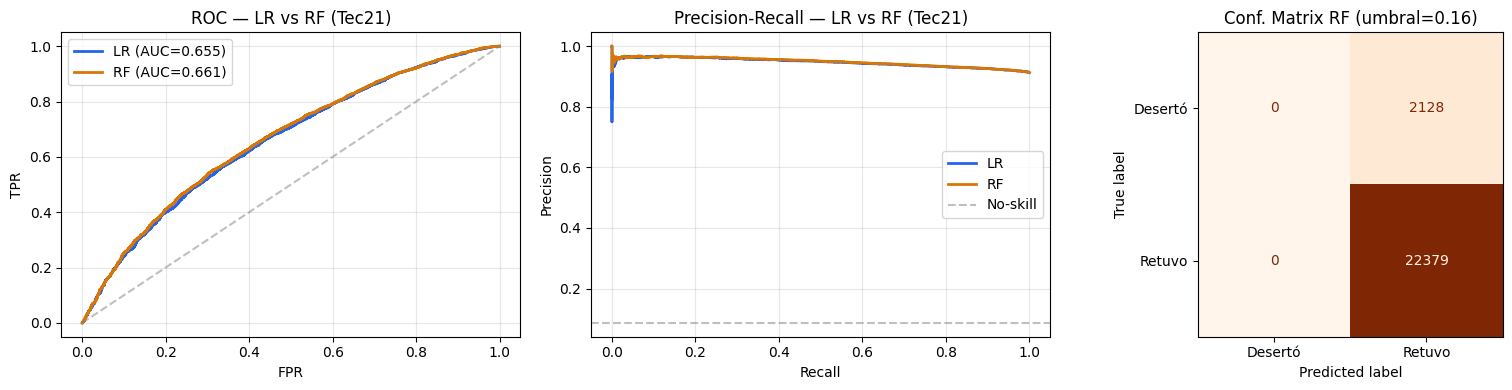

In [ ]:
# ── 2.1c.4  Curvas ROC y PR del RF + Matriz de confusión ────────────────────
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
prec_rf_c, rec_rf_c, _ = precision_recall_curve(y_test, y_proba_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(fpr_lr, tpr_lr, lw=2, color='#2563eb', label=f'LR (AUC={auc_lr:.3f})')
axes[0].plot(fpr_rf, tpr_rf, lw=2, color='#d97706', label=f'RF (AUC={auc_rf:.3f})')
axes[0].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — LR vs RF (Tec21)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec_lr_c, prec_lr_c, lw=2, color='#2563eb', label='LR')
axes[1].plot(rec_rf_c, prec_rf_c, lw=2, color='#d97706', label='RF')
axes[1].axhline((y_test==0).mean(), linestyle='--', color='gray', alpha=0.5, label='No-skill')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall — LR vs RF (Tec21)'); axes[1].legend(); axes[1].grid(alpha=0.3)

ConfusionMatrixDisplay(cm_rf, display_labels=['Desertó','Retuvo']).plot(ax=axes[2], colorbar=False, cmap='Oranges')
axes[2].set_title(f'Conf. Matrix RF (umbral={best_thr_rf:.2f})')

plt.tight_layout(); plt.show()

Calculando permutation importance (puede tardar ~1 min)...


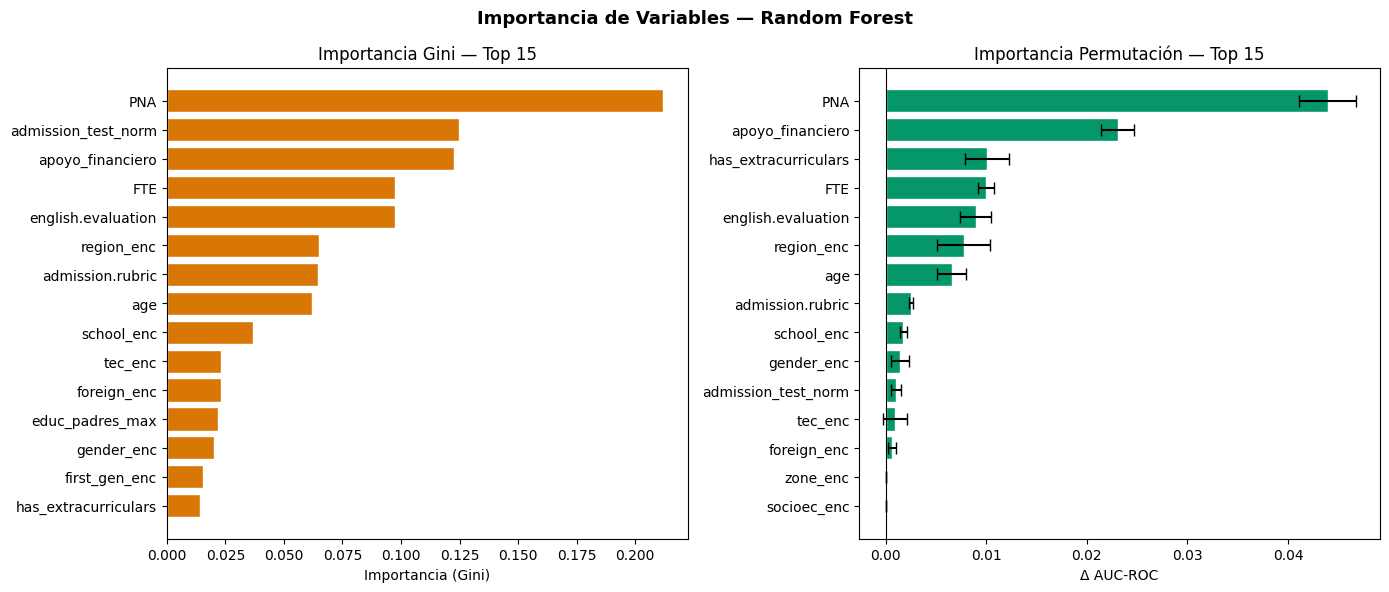


Top 10 variables — Gini:
PNA                    0.211758
admission_test_norm    0.124867
apoyo_financiero       0.122535
FTE                    0.097354
english.evaluation     0.097254
region_enc             0.064990
admission.rubric       0.064722
age                    0.061913
school_enc             0.036942
tec_enc                0.023177

Top 10 variables — Permutación:
PNA                     0.043959
apoyo_financiero        0.023080
has_extracurriculars    0.010062
FTE                     0.009986
english.evaluation      0.008944
region_enc              0.007760
age                     0.006566
admission.rubric        0.002529
school_enc              0.001762
gender_enc              0.001412


In [ ]:
# ── 2.1c.5  Importancia de variables (Gini + Permutación) ───────────────────
# Gini importance
gini_imp = pd.Series(rf_final.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

# Permutation importance (más robusta)
print("Calculando permutation importance (puede tardar ~1 min)...")
perm = permutation_importance(rf_final, X_test_sc, y_test, n_repeats=15,
                               random_state=SEED, scoring='roc_auc', n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_n = 15

gini_top = gini_imp.head(top_n)
axes[0].barh(gini_top.index[::-1], gini_top.values[::-1], color='#d97706', edgecolor='white')
axes[0].set_title(f'Importancia Gini — Top {top_n}'); axes[0].set_xlabel('Importancia (Gini)')

perm_top = perm_imp.head(top_n)
axes[1].barh(perm_top.index[::-1], perm_top.values[::-1],
             xerr=perm.importances_std[perm_imp.argsort()[::-1][:top_n]][::-1],
             color='#059669', edgecolor='white', capsize=4)
axes[1].set_title(f'Importancia Permutación — Top {top_n}'); axes[1].set_xlabel('Δ AUC-ROC')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Importancia de Variables — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nTop 10 variables — Gini:")
print(gini_imp.head(10).to_string())
print("\nTop 10 variables — Permutación:")
print(perm_imp.head(10).to_string())

# REGRESION LOGISTICA POR CLUSTER 
ESTO ES LO MIO


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

# ======================================================
# CONFIGURACIÓN
# ======================================================

SEED = 42

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# ======================================================
# FUNCIÓN PARA ENTRENAR MODELOS POR CLUSTER
# ======================================================

def evaluate_clusters(df, dataset_name):

    print(f"\n==============================")
    print(f"DATASET: {dataset_name}")
    print(f"==============================")

    clusters = sorted(df["cluster"].unique())

    results = []

    for c in clusters:

        print(f"\n----- Cluster {c} -----")

        # ==========================================
        # Filtrar cluster
        # ==========================================

        df_cluster = df[df["cluster"] == c].copy()

        print("Tamaño:", df_cluster.shape)

        # ==========================================
        # Separar X y y
        # ==========================================

        X = df_cluster.drop(columns=["retention", "cluster"])
        y = df_cluster["retention"]

        print("X:", X.shape)
        print("y:", y.shape)

        print("\nDistribución clases:")
        print(y.value_counts())

        # ==========================================
        # Modelo
        # ==========================================

        lr = LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            random_state=SEED,
            solver='lbfgs'
        )

        # ==========================================
        # Cross Validation
        # ==========================================

        cv_lr = cross_validate(
            lr,
            X,
            y,
            cv=skf,
            scoring=[
                'roc_auc',
                'recall',
                'f1',
                'precision'
            ],
            return_train_score=True,
            n_jobs=-1
        )

        # ==========================================
        # Resultados
        # ==========================================

        auc_mean = cv_lr['test_roc_auc'].mean()
        recall_mean = cv_lr['test_recall'].mean()
        f1_mean = cv_lr['test_f1'].mean()
        precision_mean = cv_lr['test_precision'].mean()

        print(f"\nAUC-ROC  : {auc_mean:.3f}")
        print(f"Recall   : {recall_mean:.3f}")
        print(f"F1-Score : {f1_mean:.3f}")
        print(f"Precision: {precision_mean:.3f}")

        results.append({
            "dataset": dataset_name,
            "cluster": c,
            "auc": auc_mean,
            "recall": recall_mean,
            "f1": f1_mean,
            "precision": precision_mean
        })

    return pd.DataFrame(results)


# ======================================================
# EVALUAR TEC20
# ======================================================

results_train = evaluate_clusters(
    cluster_train,
    "Tec20"
)

# ======================================================
# EVALUAR TEC21
# ======================================================

results_test = evaluate_clusters(
    cluster_test,
    "Tec21"
)

# ======================================================
# RESULTADOS FINALES
# ======================================================

final_results = pd.concat([
    results_train,
    results_test
])

print("\n==============================")
print("RESULTADOS FINALES")
print("==============================")

print(final_results)


DATASET: Tec20

----- Cluster 0 -----
Tamaño: (5694, 21)
X: (5694, 19)
y: (5694,)

Distribución clases:
retention
1    5421
0     273
Name: count, dtype: int64

AUC-ROC  : 0.674
Recall   : 0.668
F1-Score : 0.791
Precision: 0.970

----- Cluster 1 -----
Tamaño: (18392, 21)
X: (18392, 19)
y: (18392,)

Distribución clases:
retention
1    17259
0     1133
Name: count, dtype: int64

AUC-ROC  : 0.632
Recall   : 0.648
F1-Score : 0.772
Precision: 0.955

----- Cluster 2 -----
Tamaño: (2586, 21)
X: (2586, 19)
y: (2586,)

Distribución clases:
retention
1    2318
0     268
Name: count, dtype: int64

AUC-ROC  : 0.676
Recall   : 0.649
F1-Score : 0.765
Precision: 0.933

----- Cluster 3 -----
Tamaño: (24270, 21)
X: (24270, 19)
y: (24270,)

Distribución clases:
retention
1    21577
0     2693
Name: count, dtype: int64

AUC-ROC  : 0.645
Recall   : 0.680
F1-Score : 0.783
Precision: 0.921

----- Cluster 4 -----
Tamaño: (1667, 21)
X: (1667, 19)
y: (1667,)

Distribución clases:
retention
1    1430
0     237

In [ ]:
Código Python: análisis SHAP por cluster con comparación entre modelos educativos Tec20 y Tec21
Bloque 1 — instalación y función SHAP por cluster
# ======================================================
# ANÁLISIS SHAP POR CLUSTER
# ======================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

shap.initjs()

SEED = 42

# ======================================================
# FUNCIÓN: SHAP POR CLUSTER PARA UN DATASET
# ======================================================

def compute_shap_by_cluster(df, dataset_name):
    """
    Entrena LR por cluster, calcula SHAP y retorna
    dict {cluster: (shap_values, feature_names, X_df)}
    """
    clusters = sorted(df["cluster"].unique())
    shap_results = {}

    for c in clusters:
        df_c = df[df["cluster"] == c].copy()
        X = df_c.drop(columns=["retention", "cluster"])
        y = df_c["retention"]

        # Escalar (necesario para LR + SHAP lineal)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

        # Entrenar modelo completo (sin CV, para SHAP)
        lr = LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            random_state=SEED,
            solver='lbfgs'
        )
        lr.fit(X_scaled, y)

        # Explainer lineal (exacto para LR)
        explainer = shap.LinearExplainer(lr, X_scaled_df)
        shap_vals = explainer.shap_values(X_scaled_df)

        # Si multiclass, tomar clase positiva (retención=1)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]

        shap_results[c] = {
            "shap_values": shap_vals,
            "X": X_scaled_df,
            "feature_names": list(X.columns),
            "dataset": dataset_name,
            "cluster": c
        }
        print(f"[{dataset_name}] Cluster {c}: SHAP calculado ({X.shape[0]} obs)")

    return shap_results
Bloque 2 — ranking de importancia media por cluster
# ======================================================
# FUNCIÓN: TABLA DE RANKING DE VARIABLES POR CLUSTER
# ======================================================

def get_shap_ranking(shap_result):
    """Retorna DataFrame con ranking |mean SHAP| por feature."""
    shap_vals = shap_result["shap_values"]
    features  = shap_result["feature_names"]

    mean_abs = np.abs(shap_vals).mean(axis=0)
    df_rank = pd.DataFrame({
        "feature": features,
        "mean_abs_shap": mean_abs
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    df_rank["rank"] = df_rank.index + 1
    df_rank["dataset"]  = shap_result["dataset"]
    df_rank["cluster"]  = shap_result["cluster"]
    return df_rank




[Tec20] Cluster 0: SHAP calculado (5694 obs)
[Tec20] Cluster 1: SHAP calculado (18392 obs)
[Tec20] Cluster 2: SHAP calculado (2586 obs)
[Tec20] Cluster 3: SHAP calculado (24270 obs)
[Tec20] Cluster 4: SHAP calculado (1667 obs)
[Tec20] Cluster 5: SHAP calculado (401 obs)
[Tec21] Cluster 0: SHAP calculado (7510 obs)
[Tec21] Cluster 1: SHAP calculado (8337 obs)
[Tec21] Cluster 2: SHAP calculado (3997 obs)
[Tec21] Cluster 3: SHAP calculado (938 obs)
[Tec21] Cluster 4: SHAP calculado (2894 obs)
[Tec21] Cluster 5: SHAP calculado (831 obs)


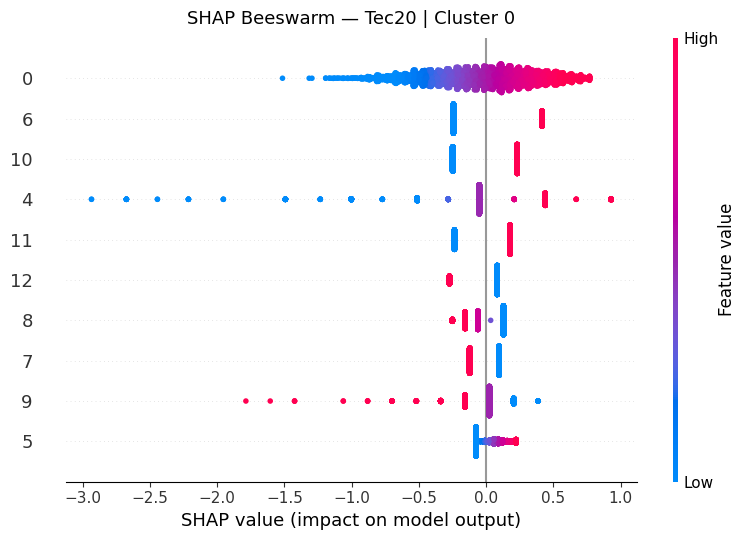

Guardado: shap_beeswarm_Tec20_cluster0.png



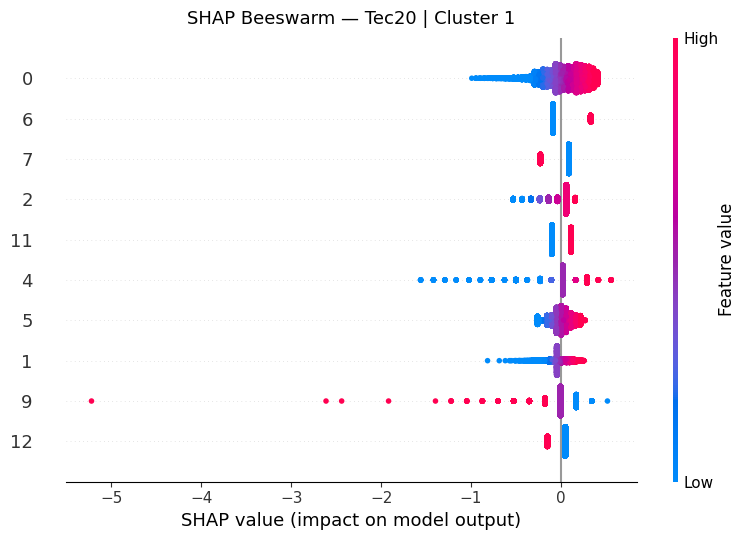

Guardado: shap_beeswarm_Tec20_cluster1.png



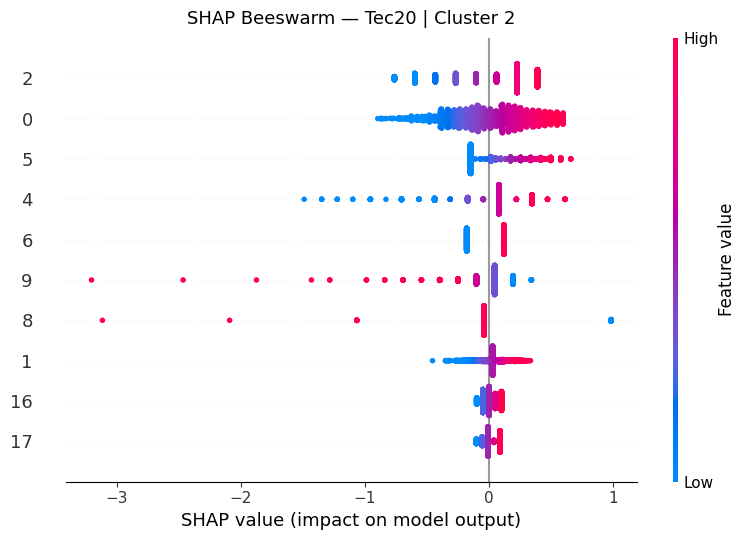

Guardado: shap_beeswarm_Tec20_cluster2.png



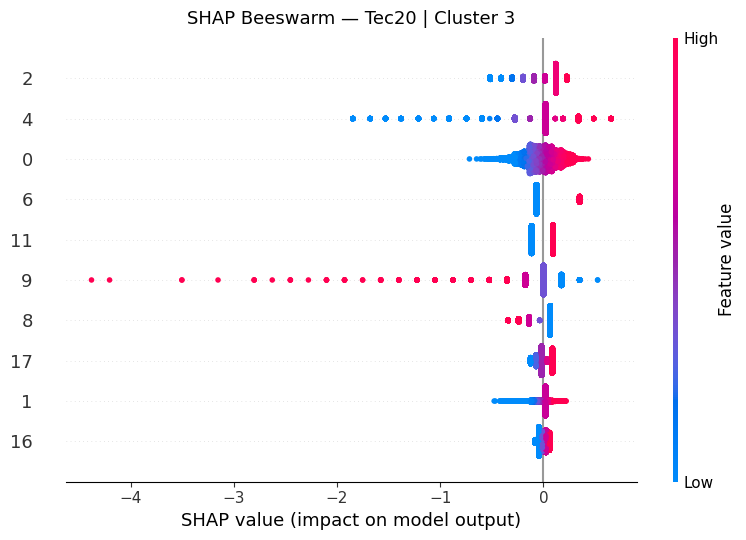

Guardado: shap_beeswarm_Tec20_cluster3.png



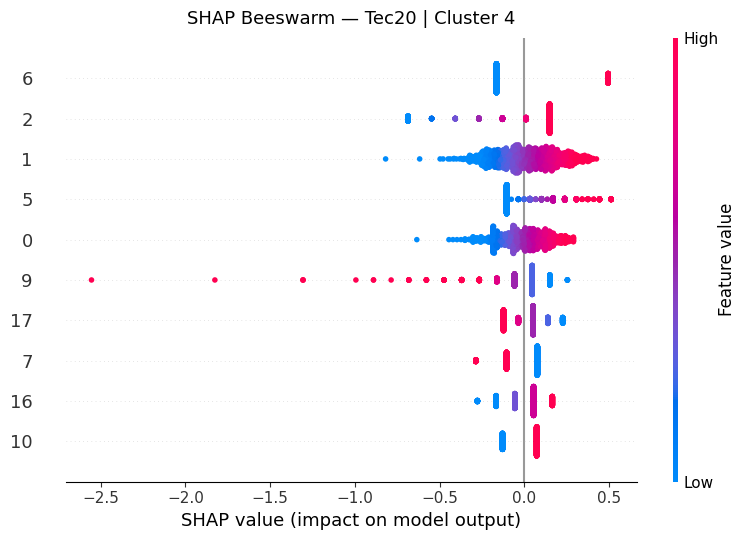

Guardado: shap_beeswarm_Tec20_cluster4.png



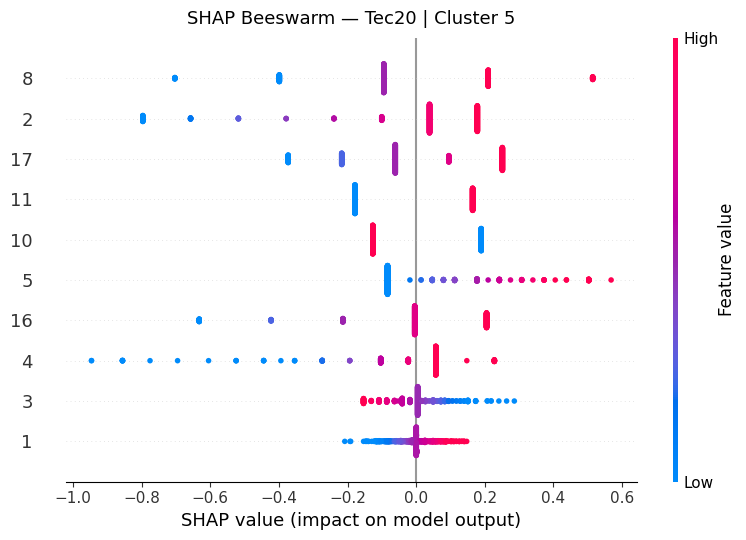

Guardado: shap_beeswarm_Tec20_cluster5.png



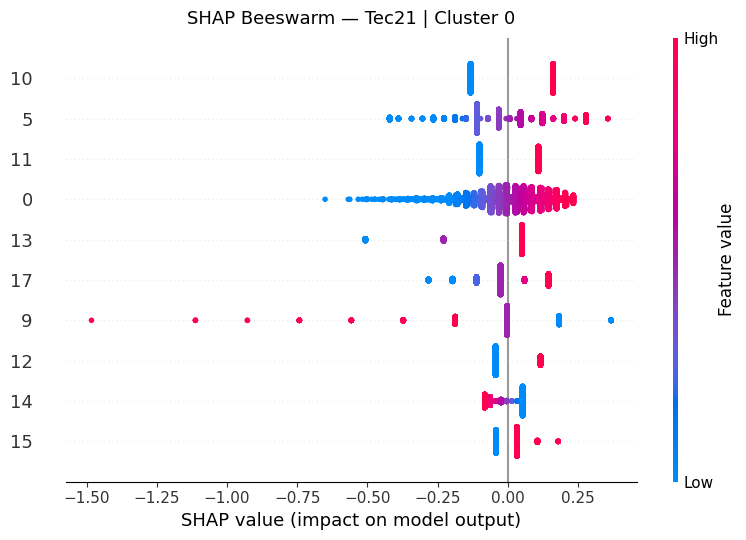

Guardado: shap_beeswarm_Tec21_cluster0.png



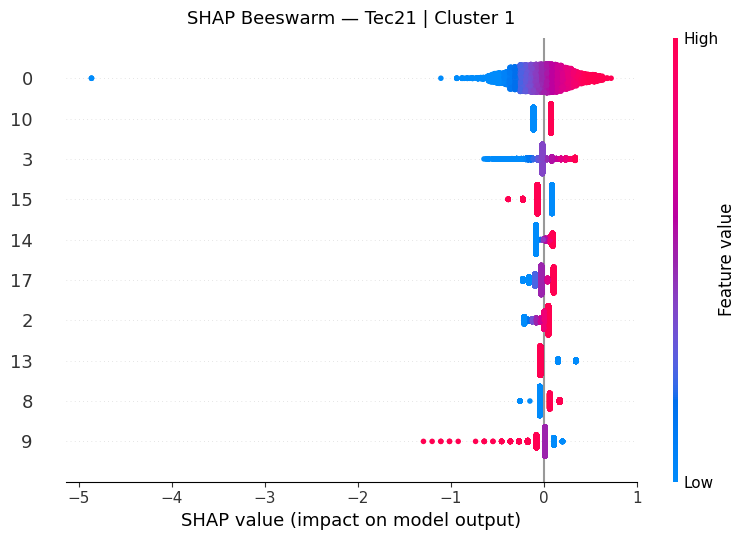

Guardado: shap_beeswarm_Tec21_cluster1.png



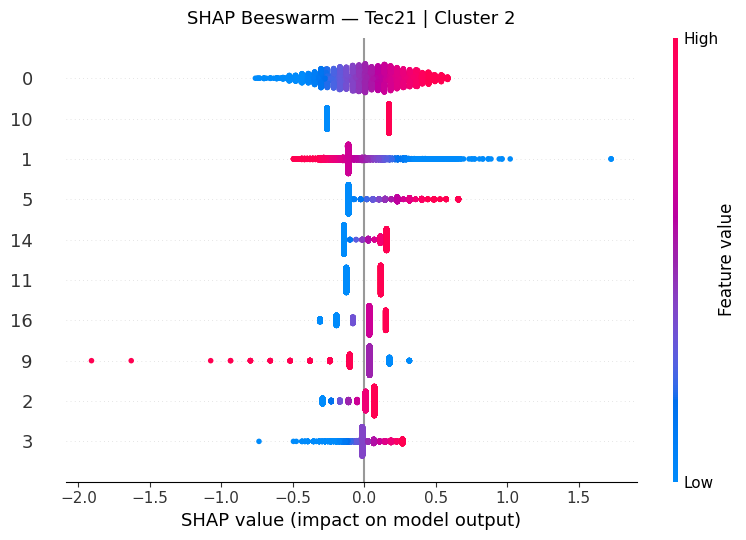

Guardado: shap_beeswarm_Tec21_cluster2.png



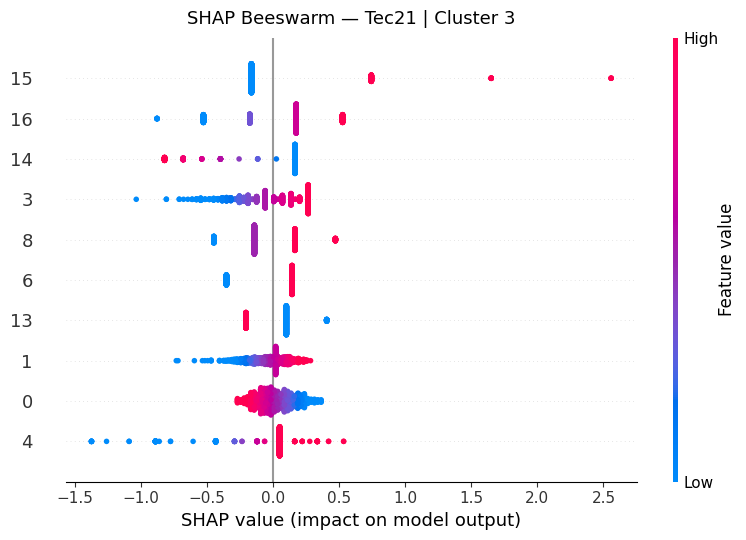

Guardado: shap_beeswarm_Tec21_cluster3.png



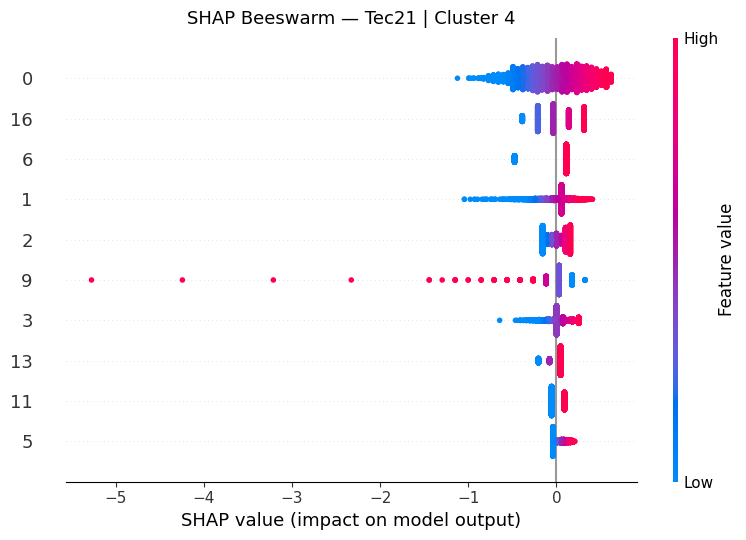

Guardado: shap_beeswarm_Tec21_cluster4.png



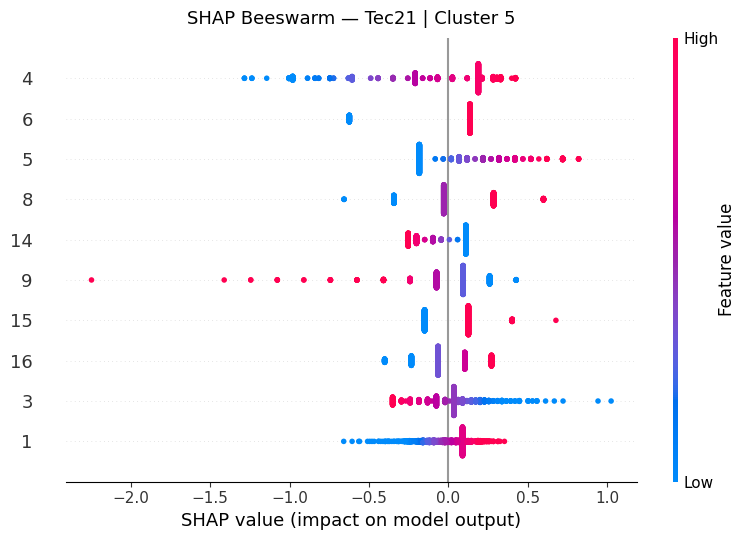

Guardado: shap_beeswarm_Tec21_cluster5.png



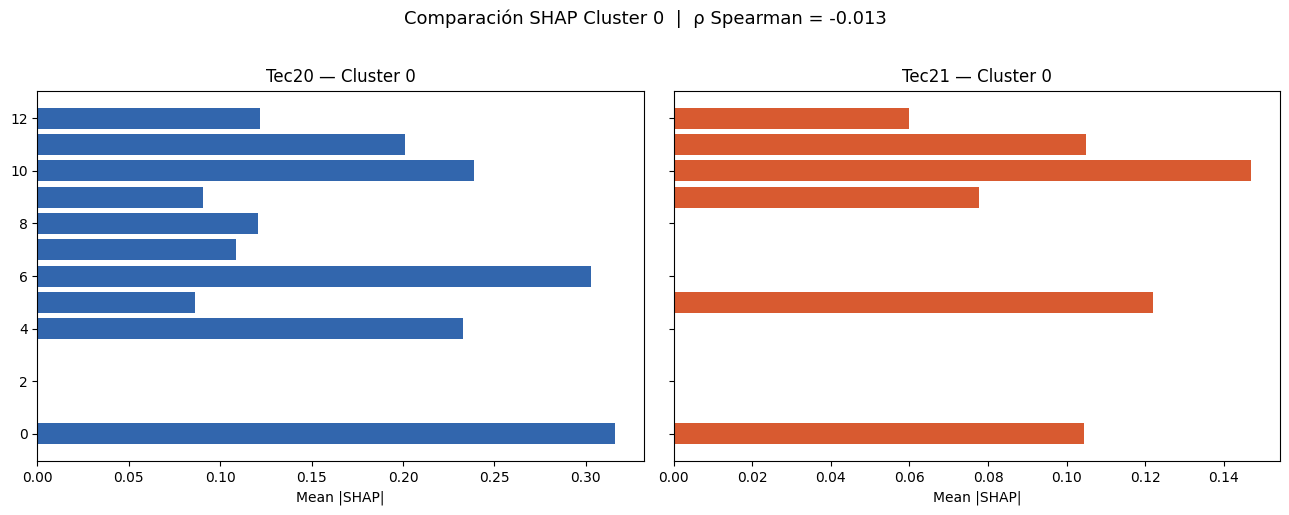

Guardado: shap_compare_cluster0.png
  Spearman ρ = -0.013  (p = 0.9726)



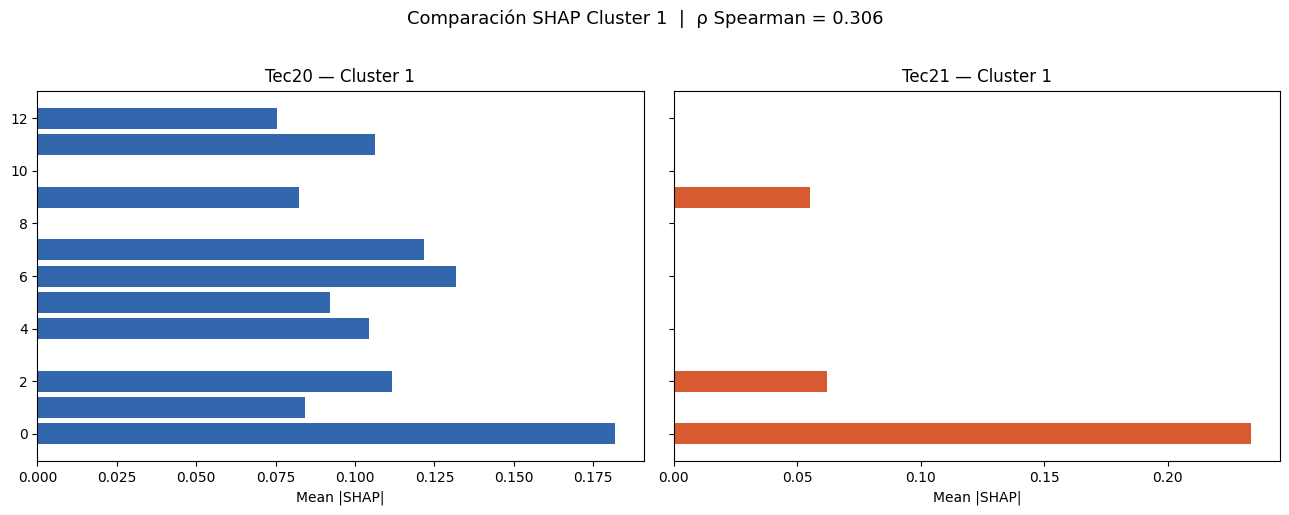

Guardado: shap_compare_cluster1.png
  Spearman ρ = 0.306  (p = 0.3903)



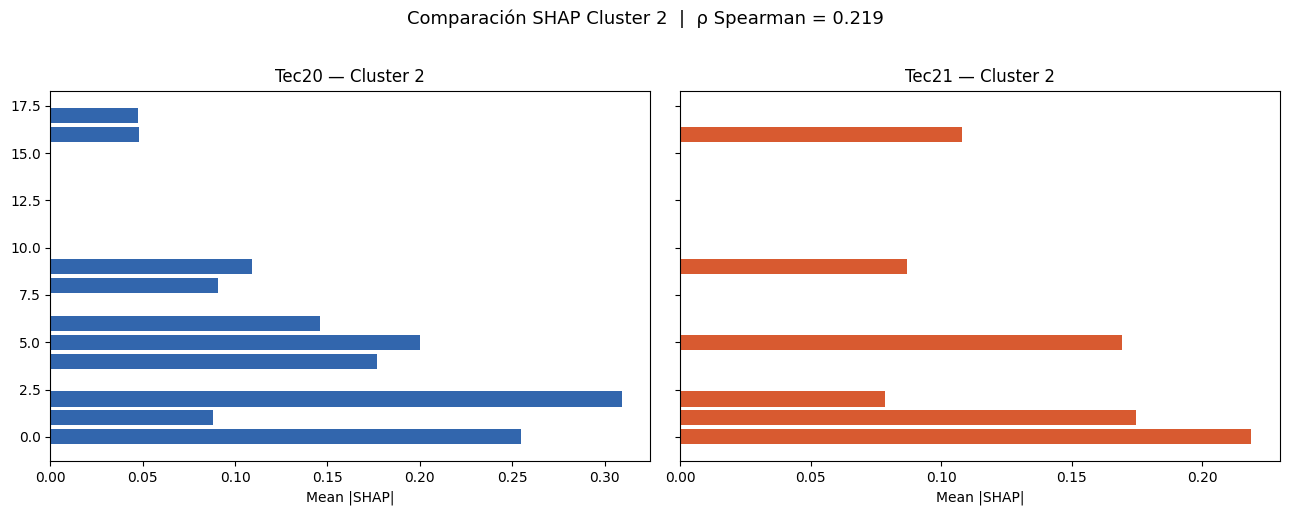

Guardado: shap_compare_cluster2.png
  Spearman ρ = 0.219  (p = 0.5435)



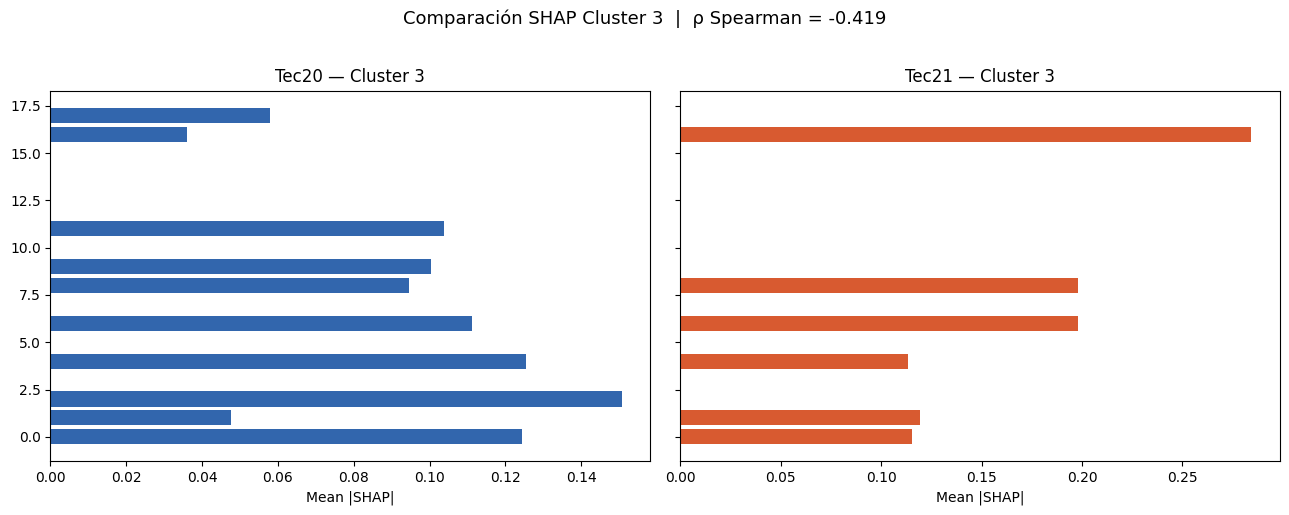

Guardado: shap_compare_cluster3.png
  Spearman ρ = -0.419  (p = 0.2282)



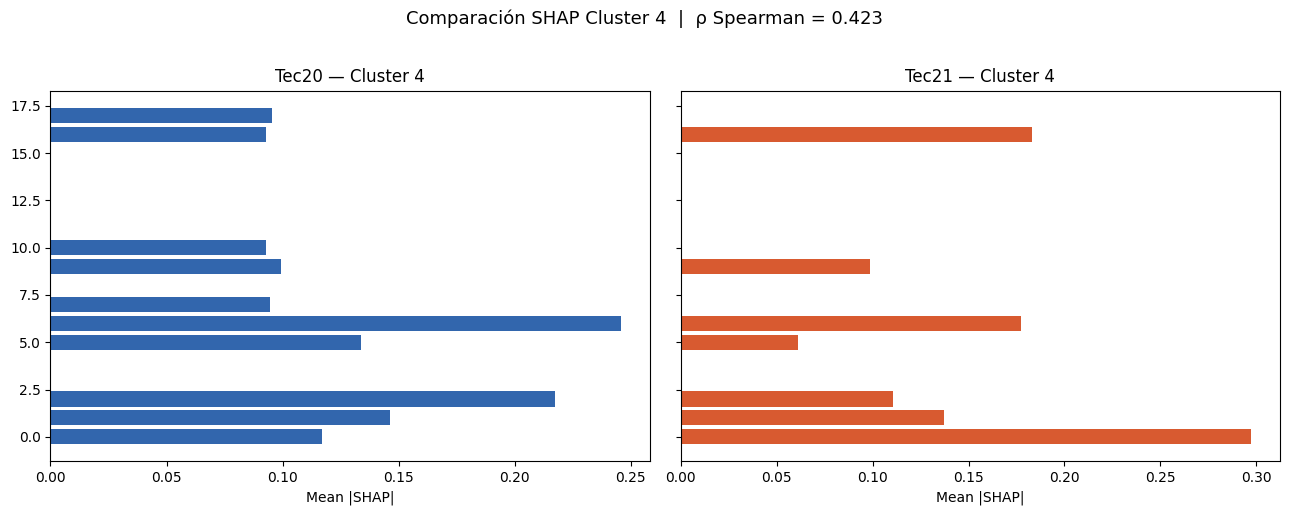

Guardado: shap_compare_cluster4.png
  Spearman ρ = 0.423  (p = 0.2228)



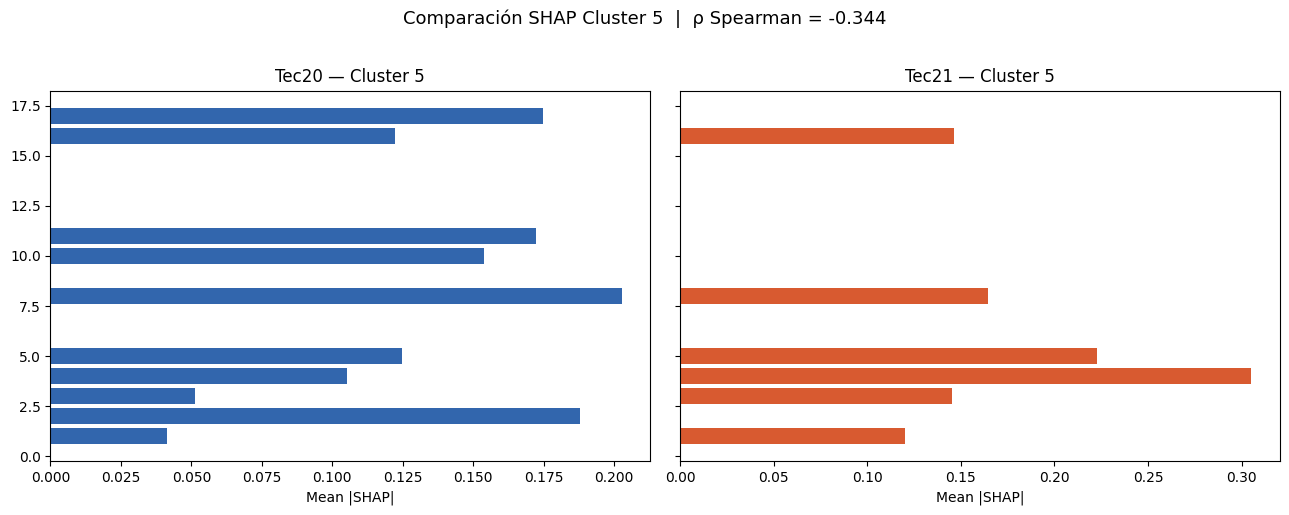

Guardado: shap_compare_cluster5.png
  Spearman ρ = -0.344  (p = 0.3305)


CORRELACIÓN SPEARMAN POR CLUSTER
 cluster  spearman_rho  p_value
       0     -0.012506 0.972647
       1      0.305723 0.390310
       2      0.218857 0.543530
       3     -0.418955 0.228164
       4      0.423345 0.222818
       5     -0.343918 0.330526


In [55]:
# ======================================================
# ANÁLISIS SHAP POR CLUSTER
# ======================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

shap.initjs()

SEED = 42

# ======================================================
# FUNCIÓN: SHAP POR CLUSTER PARA UN DATASET
# ======================================================

def compute_shap_by_cluster(df, dataset_name):
    """
    Entrena LR por cluster, calcula SHAP y retorna
    dict {cluster: (shap_values, feature_names, X_df)}
    """
    clusters = sorted(df["cluster"].unique())
    shap_results = {}

    for c in clusters:
        df_c = df[df["cluster"] == c].copy()
        X = df_c.drop(columns=["retention", "cluster"])
        y = df_c["retention"]

        # Escalar (necesario para LR + SHAP lineal)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

        # Entrenar modelo completo (sin CV, para SHAP)
        lr = LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            random_state=SEED,
            solver='lbfgs'
        )
        lr.fit(X_scaled, y)

        # Explainer lineal (exacto para LR)
        explainer = shap.LinearExplainer(lr, X_scaled_df)
        shap_vals = explainer.shap_values(X_scaled_df)

        # Si multiclass, tomar clase positiva (retención=1)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]

        shap_results[c] = {
            "shap_values": shap_vals,
            "X": X_scaled_df,
            "feature_names": list(X.columns),
            "dataset": dataset_name,
            "cluster": c
        }
        print(f"[{dataset_name}] Cluster {c}: SHAP calculado ({X.shape[0]} obs)")

    return shap_results
# Bloque 2 — ranking de importancia media por cluster
# ======================================================
# FUNCIÓN: TABLA DE RANKING DE VARIABLES POR CLUSTER
# ======================================================

def get_shap_ranking(shap_result):
    """Retorna DataFrame con ranking |mean SHAP| por feature."""
    shap_vals = shap_result["shap_values"]
    features  = shap_result["feature_names"]

    mean_abs = np.abs(shap_vals).mean(axis=0)
    df_rank = pd.DataFrame({
        "feature": features,
        "mean_abs_shap": mean_abs
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    df_rank["rank"] = df_rank.index + 1
    df_rank["dataset"]  = shap_result["dataset"]
    df_rank["cluster"]  = shap_result["cluster"]
    return df_rank


def build_all_rankings(shap_dict):
    """Concatena rankings de todos los clusters de un dataset."""
    frames = [get_shap_ranking(v) for v in shap_dict.values()]
    return pd.concat(frames, ignore_index=True)
# Bloque 3 — plots SHAP beeswarm individuales
# ======================================================
# FUNCIÓN: BEESWARM POR CLUSTER (individual)
# ======================================================

def plot_shap_beeswarm_per_cluster(shap_dict, top_n=10):
    """
    Genera un beeswarm SHAP por cada cluster del dataset.
    Muestra las top_n variables más importantes.
    """
    for c, res in shap_dict.items():
        shap_vals = res["shap_values"]
        X         = res["X"]
        dataset   = res["dataset"]

        # Seleccionar top N features por |mean SHAP|
        mean_abs = np.abs(shap_vals).mean(axis=0)
        top_idx  = np.argsort(mean_abs)[::-1][:top_n]

        shap_top = shap_vals[:, top_idx]
        X_top    = X.iloc[:, top_idx]

        expl = shap.Explanation(
            values=shap_top,
            data=X_top.values,
            feature_names=list(X_top.columns)
        )

        plt.figure(figsize=(8, 5))
        shap.plots.beeswarm(expl, show=False, max_display=top_n)
        plt.title(f"SHAP Beeswarm — {dataset} | Cluster {c}",
                  fontsize=13, pad=10)
        plt.tight_layout()
        plt.savefig(f"shap_beeswarm_{dataset}_cluster{c}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Guardado: shap_beeswarm_{dataset}_cluster{c}.png\n")
# Bloque 4 — comparación Tec20 vs Tec21 por cluster (heatmap de ranks)
# ======================================================
# FUNCIÓN: COMPARAR MISMO CLUSTER ENTRE DATASETS
# ======================================================

def compare_clusters_across_datasets(rankings_tec20, rankings_tec21,
                                       top_n=10):
    """
    Para cada cluster compartido entre Tec20 y Tec21:
    - Muestra ranking lado a lado (bar chart horizontal)
    - Calcula correlación de Spearman entre rankings
    - Resalta variables que cambian de posición
    """
    from scipy.stats import spearmanr

    clusters_20 = set(rankings_tec20["cluster"].unique())
    clusters_21 = set(rankings_tec21["cluster"].unique())
    common_clusters = sorted(clusters_20 & clusters_21)

    corr_summary = []

    for c in common_clusters:
        r20 = (rankings_tec20[rankings_tec20["cluster"] == c]
               .nsmallest(top_n, "rank")
               .set_index("feature")["mean_abs_shap"])

        r21 = (rankings_tec21[rankings_tec21["cluster"] == c]
               .nsmallest(top_n, "rank")
               .set_index("feature")["mean_abs_shap"])

        # Unión de features top-N de ambos datasets
        all_feats = list(dict.fromkeys(
            list(r20.index) + [f for f in r21.index if f not in r20.index]
        ))[:top_n]

        vals20 = [r20.get(f, 0) for f in all_feats]
        vals21 = [r21.get(f, 0) for f in all_feats]

        # Correlación Spearman sobre los ranks
        rank20 = pd.Series(vals20).rank(ascending=False)
        rank21 = pd.Series(vals21).rank(ascending=False)
        rho, pval = spearmanr(rank20, rank21)

        corr_summary.append({"cluster": c, "spearman_rho": rho, "p_value": pval})

        # ---- Plot comparativo ----
        fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

        colors20 = ["#3266ad" if v > 0 else "#c8c8c0" for v in vals20]
        colors21 = ["#D85A30" if v > 0 else "#c8c8c0" for v in vals21]

        axes[0].barh(all_feats[::-1], vals20[::-1], color=colors20[::-1])
        axes[0].set_title(f"Tec20 — Cluster {c}", fontsize=12)
        axes[0].set_xlabel("Mean |SHAP|")

        axes[1].barh(all_feats[::-1], vals21[::-1], color=colors21[::-1])
        axes[1].set_title(f"Tec21 — Cluster {c}", fontsize=12)
        axes[1].set_xlabel("Mean |SHAP|")

        fig.suptitle(
            f"Comparación SHAP Cluster {c}  |  ρ Spearman = {rho:.3f}",
            fontsize=13, y=1.02
        )
        plt.tight_layout()
        plt.savefig(f"shap_compare_cluster{c}.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Guardado: shap_compare_cluster{c}.png")
        print(f"  Spearman ρ = {rho:.3f}  (p = {pval:.4f})\n")

    return pd.DataFrame(corr_summary)
# Bloque 5 — heatmap global de ranking por cluster × dataset
# ======================================================
# FUNCIÓN: HEATMAP GLOBAL DE RANKS
# ======================================================

def plot_rank_heatmap(rankings_tec20, rankings_tec21, top_n=12):
    """
    Heatmap: filas = features globales top_n, columnas = (dataset, cluster).
    Celda = rank de esa variable en ese cluster.
    Permite ver de un vistazo si el orden se conserva.
    """
    all_rankings = pd.concat([rankings_tec20, rankings_tec21])

    # Top N features globales (por promedio de mean_abs_shap)
    top_feats = (
        all_rankings.groupby("feature")["mean_abs_shap"]
        .mean()
        .nlargest(top_n)
        .index.tolist()
    )

    all_rankings["col_key"] = (
        all_rankings["dataset"] + " · C" + all_rankings["cluster"].astype(str)
    )

    pivot = (
        all_rankings[all_rankings["feature"].isin(top_feats)]
        .pivot_table(index="feature", columns="col_key", values="rank")
        .reindex(top_feats)
    )

    fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns) * 1.4),
                                     top_n * 0.55 + 1.5))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r",
                   vmin=1, vmax=top_n)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha="right", fontsize=10)
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels(top_feats, fontsize=10)

    for i in range(len(top_feats)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            txt = str(int(val)) if not np.isnan(val) else "–"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9,
                    color="white" if (not np.isnan(val) and val > top_n/2) else "black")

    plt.colorbar(im, ax=ax, label="Rank (1 = más importante)", shrink=0.7)
    ax.set_title("Ranking SHAP — Comparación Tec20 vs Tec21 por Cluster",
                 fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig("shap_rank_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Guardado: shap_rank_heatmap.png")
# Bloque 6 — ejecución completa
# ======================================================
# EJECUCIÓN
# ======================================================

# 1. Calcular SHAP por cluster para cada dataset
shap_tec20 = compute_shap_by_cluster(cluster_train, "Tec20")
shap_tec21 = compute_shap_by_cluster(cluster_test,  "Tec21")

# 2. Construir tablas de ranking
rankings_20 = build_all_rankings(shap_tec20)
rankings_21 = build_all_rankings(shap_tec21)

# 3. Beeswarm individuales (opcional)
plot_shap_beeswarm_per_cluster(shap_tec20, top_n=10)
plot_shap_beeswarm_per_cluster(shap_tec21, top_n=10)

# 4. Comparación cluster a cluster entre datasets
corr_df = compare_clusters_across_datasets(rankings_20, rankings_21, top_n=10)

print("\n==============================")
print("CORRELACIÓN SPEARMAN POR CLUSTER")
print("==============================")
print(corr_df.to_string(index=False))


In [56]:

from scipy.stats import spearmanr
import pandas as pd
import numpy as np

def get_rank_vector(shap_result):
    """
    Retorna Serie: feature → rank ordinal (1 = más importante).
    Rank basado en posición, no en valor SHAP.
    """
    shap_vals   = shap_result["shap_values"]
    features    = shap_result["feature_names"]
    mean_abs    = np.abs(shap_vals).mean(axis=0)
    order       = np.argsort(mean_abs)[::-1]   # de mayor a menor
    ranks       = {features[i]: pos + 1
                   for pos, i in enumerate(order)}
    return pd.Series(ranks, name="rank")
# Paso 2 — comparar el orden entre dos clusters (uno por dataset)
def compare_rank_order(rank_vec_20, rank_vec_21):
    """
    Dados dos vectores rank (feature → posición),
    alinea por nombre de feature y calcula Spearman
    sobre posiciones, no sobre valores SHAP.

    Pregunta: ¿la feature que es #1 en Tec20
              también es #1 en Tec21?
    """
    # Alinear: solo features presentes en ambos
    common = rank_vec_20.index.intersection(rank_vec_21.index)
    r20 = rank_vec_20[common]
    r21 = rank_vec_21[common]

    rho, pval = spearmanr(r20.values, r21.values)
    return rho, pval, r20, r21


def build_rank_comparison_table(rank_vec_20, rank_vec_21,
                                   label_20="Tec20",
                                   label_21="Tec21"):
    """
    Tabla legible: feature, rank_tec20, rank_tec21,
    delta (diferencia de posición), interpretación.
    """
    rho, pval, r20, r21 = compare_rank_order(rank_vec_20, rank_vec_21)

    df = pd.DataFrame({
        label_20 : r20,
        label_21 : r21
    }).sort_values(label_20)   # orden según Tec20

    df["delta"]         = (df[label_21] - df[label_20]).abs()
    df["subio_bajo"]    = df[label_21] - df[label_20]
    df["consistente"]   = df["delta"] <= 2   # ±2 posiciones = estable

    print(f"Spearman ρ = {rho:.3f}  |  p = {pval:.4f}")
    print(f"Features consistentes (Δ≤2): {df['consistente'].sum()}/{len(df)}\n")
    print(df[[label_20, label_21, "delta", "subio_bajo", "consistente"]]
          .to_string())
    return df, rho, pval
# Paso 3 — alineación de clusters (crítico si se corrió clustering por separado)
def align_clusters(shap_tec20, shap_tec21):
    """
    Si los clusters se generaron por separado, el cluster 0
    de Tec20 puede NO ser el mismo perfil que el cluster 0
    de Tec21. Este paso los alinea por similitud de rankings.

    Estrategia: para cada cluster de Tec20, encuentra el
    cluster de Tec21 con mayor correlación de Spearman.
    Retorna dict {cluster_tec20 → cluster_tec21_más_similar}
    """
    clusters_20 = list(shap_tec20.keys())
    clusters_21 = list(shap_tec21.keys())

    alignment = {}
    corr_matrix = pd.DataFrame(index=clusters_20, columns=clusters_21, dtype=float)

    for c20 in clusters_20:
        rv20 = get_rank_vector(shap_tec20[c20])
        best_rho, best_c21 = -2, None
        for c21 in clusters_21:
            rv21 = get_rank_vector(shap_tec21[c21])
            rho, _ = compare_rank_order(rv20, rv21)[:2]
            corr_matrix.loc[c20, c21] = rho
            if rho > best_rho:
                best_rho, best_c21 = rho, c21
        alignment[c20] = (best_c21, best_rho)

    print("Matriz de correlación entre todos los pares de clusters:")
    print(corr_matrix.round(3).to_string())

    print("\nMejor alineación sugerida:")
    for c20, (c21, rho) in alignment.items():
        print(f"  Tec20 C{c20}  →  Tec21 C{c21}  (ρ = {rho:.3f})")

    return alignment, corr_matrix
# Paso 4 — ejecución completa con alineación automática
# ── 1. Rank vectors para todos los clusters ──────────────
ranks_tec20 = {c: get_rank_vector(res) for c, res in shap_tec20.items()}
ranks_tec21 = {c: get_rank_vector(res) for c, res in shap_tec21.items()}

# ── 2. Alinear clusters entre datasets ───────────────────
alignment, corr_matrix = align_clusters(shap_tec20, shap_tec21)

# ── 3. Comparar cada par alineado ────────────────────────
summary = []

for c20, (c21, _) in alignment.items():

    print(f"\n{'='*50}")
    print(f"Tec20 Cluster {c20}  ↔  Tec21 Cluster {c21}")
    print('='*50)

    df_cmp, rho, pval = build_rank_comparison_table(
        ranks_tec20[c20],
        ranks_tec21[c21],
        label_20=f"Tec20_C{c20}",
        label_21=f"Tec21_C{c21}"
    )
    summary.append({
        "cluster_tec20"   : c20,
        "cluster_tec21"   : c21,
        "spearman_rho"    : rho,
        "p_value"         : pval,
        "n_consistentes"  : int(df_cmp["consistente"].sum()),
        "n_features"      : len(df_cmp),
        "top1_igual"      : (df_cmp.iloc[0][f"Tec21_C{c21}"] == 1)
    })

# ── 4. Resumen final ─────────────────────────────────────
summary_df = pd.DataFrame(summary)
print("\n" + "="*50)
print("RESUMEN: ESTABILIDAD DEL ORDEN DE VARIABLES")
print("="*50)
print(summary_df.to_string(index=False))
# Qué leer en el output
# # spearman_rho  →  orden idéntico = 1.0  |  orden inverso = -1.0  |  aleatorio ≈ 0
# # p_value       →  < 0.05: el orden NO es por azar (con N=19 features)
# # n_consistentes→  features que no se mueven más de ±2 posiciones
# # top1_igual    →  True si la feature #1 de Tec20 también es #1 en Tec21

# # Con 19 features, el umbral de significancia es ρ > ~0.46 (p < 0.05)
# # ρ > 0.70  →  orden muy estable entre generaciones
# # ρ 0.40–0.70 →  orden moderadamente estable
# # ρ < 0.40  →  los drivers de retención cambian entre generaciones
# Copy failed — try from claude.ai in browser

Matriz de correlación entre todos los pares de clusters:
       0      1      2      3      4      5
0  0.198 -0.125  0.072 -0.412  0.214  0.146
1 -0.019 -0.268  0.082 -0.389  0.446  0.018
2 -0.053 -0.123  0.151 -0.104  0.472  0.288
3 -0.107 -0.040  0.004 -0.163  0.495  0.079
4 -0.104 -0.098  0.221 -0.046  0.519  0.251
5  0.181  0.179  0.354 -0.251 -0.002 -0.091

Mejor alineación sugerida:
  Tec20 C0  →  Tec21 C4  (ρ = 0.214)
  Tec20 C1  →  Tec21 C4  (ρ = 0.446)
  Tec20 C2  →  Tec21 C4  (ρ = 0.472)
  Tec20 C3  →  Tec21 C4  (ρ = 0.495)
  Tec20 C4  →  Tec21 C4  (ρ = 0.519)
  Tec20 C5  →  Tec21 C2  (ρ = 0.354)

Tec20 Cluster 0  ↔  Tec21 Cluster 4
Spearman ρ = 0.214  |  p = 0.3789
Features consistentes (Δ≤2): 7/19

    Tec20_C0  Tec21_C4  delta  subio_bajo  consistente
0          1         1      0           0         True
6          2         3      1           1         True
10         3        14     11          11        False
4          4        13      9           9        False
11  